# 03 – Modellvergleich PV-Prognose

Dieses Notebook **trainiert keine Modelle**. Es lädt vorberechnete Ergebnisse aus den Kaggle-Training-Scripts und vergleicht alle Modelle systematisch.

**Ausschlüsse:**
- Chronos: eigener Abschnitt am Ende, **nicht** im direkten Vergleich
- LightGBM_SPT: im Vergleich nur mit OOS-Metriken (anderes Trainings-Dataset)

**Inhalt:** Metriken · Training Curves (DL) · Inferenzzeit · UMBRA-Simulation · Feature Importance · Gesamtranking

In [1]:
import gc, json, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mlflow
from pathlib import Path
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# ── Robuste Pfad-Erkennung (funktioniert aus bscthesis/ UND repo-root) ────────
_here = Path().resolve()
if (_here / 'bscthesis' / 'data' / 'Kaggle').exists():
    # Läuft aus dem Repo-Root
    _BASE     = _here / 'bscthesis'
    _EXP_BASE = _here / 'experiments'
else:
    # Läuft aus bscthesis/
    _BASE     = _here
    _EXP_BASE = _here.parent / 'experiments'

KR           = _BASE / 'data' / 'Kaggle_results'
KAGGLE_DIR   = KR  # Basis-Fallback
SPT_LGBM_DIR = KR / 'SPT_lgbm'
_MODEL_DIRS  = {
    'LinearRegression': KR / 'linear_regression',
    'RandomForest':  KR / 'random_forest',
    'LightGBM':      KR / 'lgbm',
    'LightGBM_SPT':  KR / 'SPT_lgbm',
    'GRU':           KR / 'GRU',
    'CNN-LSTM':      KR / 'Cnn_lstm',
    'TSMixer':       KR / 'tsmixer',
    'iTransformer':  KR / 'i_transformer',
    'Chronos':       KR / 'Chronos',
}
DATA_PATH    = _BASE / 'data' / 'processed' / 'data_final.parquet'
DATA_10_PATH = _BASE / 'data' / 'raw' / '2026_03_10'
SPT_PATH     = _EXP_BASE / 'total_pv_output' / 'data' / 'processed' / '2026-03-03_pv_with_analogs.parquet'

sys.path.insert(0, str(_BASE.parent))

PALETTE = {
    'LinearRegression': '#9edae5',
    'RandomForest':   '#f28e2b',
    'LightGBM':       '#e15759',
    'LightGBM_SPT':   '#f0a500',
    'GRU':            '#76b7b2',
    'CNN-LSTM':       '#59a14f',
    'TSMixer':        '#d4a0e8',
    'iTransformer':   '#edc948',
    'Chronos':        '#ff9da7',
    'Analog KNN':     '#aec7e8',
}

Path('modelresults').mkdir(exist_ok=True)
print('Setup complete.')
print(f'CWD:              {_here}')
print(f'Kaggle results:   {KR}  exists={KR.exists()}')
for _n, _d in _MODEL_DIRS.items(): print(f'  [{"OK" if _d.exists() else "--"}] {_n:14s} → {_d.name}')
print(f'Data path:        {DATA_PATH}  exists={DATA_PATH.exists()}')


/opt/anaconda3/lib/python3.12/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Setup complete.
CWD:              /Users/yashagrawal/Desktop/Bscthesis/richtig/ect_forecasts/bscthesis
Kaggle results:   /Users/yashagrawal/Desktop/Bscthesis/richtig/ect_forecasts/bscthesis/data/Kaggle_results  exists=True
  [OK] LinearRegression → linear_regression
  [OK] RandomForest   → random_forest
  [OK] LightGBM       → lgbm
  [OK] LightGBM_SPT   → SPT_lgbm
  [OK] GRU            → GRU
  [OK] CNN-LSTM       → Cnn_lstm
  [OK] TSMixer        → tsmixer
  [OK] iTransformer   → i_transformer
  [OK] Chronos        → Chronos
Data path:        /Users/yashagrawal/Desktop/Bscthesis/richtig/ect_forecasts/bscthesis/data/processed/data_final.parquet  exists=True


## Setup & Datenladen

Lädt die Modell-Registry, alle Ergebnisse (JSON + NumPy-Arrays), berechnet gewichtete Metriken und misst Inferenzzeit.

In [2]:
MODEL_REGISTRY = {
    # ── Klassische ML ────────────────────────────────────────────────────────
    'LinearRegression': {
        'json': 'linreg_results.json', 'preds': 'linreg_preds.npy', 'targets': 'linreg_targets.npy',
        'neural': False, 'type': 'linear', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['LinearRegression'],
    },
    'RandomForest': {
        'json': 'rf_results.json', 'preds': 'rf_preds.npy', 'targets': 'rf_targets.npy',
        'neural': False, 'type': 'tree', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['RandomForest'],
    },
    'LightGBM': {
        'json': 'lgbm_results.json', 'preds': 'lgbm_preds.npy', 'targets': 'lgbm_targets.npy',
        'neural': False, 'type': 'tree', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['LightGBM'],
    },
    'LightGBM_SPT': {
        'json': 'spt_lgbm_results.json', 'preds': 'spt_lgbm_preds.npy', 'targets': 'spt_lgbm_targets.npy',
        'neural': False, 'type': 'tree', 'is_baseline': False,
        'base_dir': SPT_LGBM_DIR,
    },
    # ── Deep Learning ────────────────────────────────────────────────────────
    'GRU': {
        'json': 'gru_results.json', 'preds': 'gru_preds.npy', 'targets': 'gru_targets.npy',
        'neural': True,  'type': 'rnn', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['GRU'],
    },
    'CNN-LSTM': {
        'json': 'cnnlstm_results.json', 'preds': 'cnnlstm_preds.npy', 'targets': 'cnnlstm_targets.npy',
        'neural': True,  'type': 'rnn', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['CNN-LSTM'],
    },
    'TSMixer': {
        'json': 'tsmixer_results.json', 'preds': 'tsmixer_preds.npy', 'targets': 'tsmixer_targets.npy',
        'neural': True,  'type': 'mlp', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['TSMixer'],
    },
    'iTransformer': {
        'json': 'itransformer_results.json', 'preds': 'itransformer_preds.npy', 'targets': 'itransformer_targets.npy',
        'neural': True,  'type': 'transformer', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['iTransformer'],
    },
    'Chronos': {
        'json': 'chronos_results.json', 'preds': 'chronos_preds.npy', 'targets': 'chronos_targets.npy',
        'neural': True,  'type': 'foundation', 'is_baseline': False,
        'base_dir': _MODEL_DIRS['Chronos'],
    },
}

print(f'Registry: {len(MODEL_REGISTRY)} Modelle')
for name, cfg in MODEL_REGISTRY.items():
    _bdir = cfg.get('base_dir', KAGGLE_DIR)
    found = (_bdir / cfg['json']).exists()
    preds_found = cfg['preds'] and (_bdir / cfg['preds']).exists()
    print(f'  [{"OK" if found else "--"}] {name:14s}  json={found}  preds={preds_found}')

Registry: 9 Modelle
  [OK] LinearRegression  json=True  preds=True
  [OK] RandomForest    json=True  preds=True
  [OK] LightGBM        json=True  preds=True
  [OK] LightGBM_SPT    json=True  preds=True
  [OK] GRU             json=True  preds=True
  [OK] CNN-LSTM        json=True  preds=True
  [OK] TSMixer         json=True  preds=True
  [OK] iTransformer    json=True  preds=True
  [OK] Chronos         json=True  preds=True


In [3]:
def compute_wrmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = y_true / (y_true.mean() + 1e-9)
    return float(np.sqrt((w * (y_pred - y_true) ** 2).sum() / (w.sum() + 1e-9)))

def compute_wmae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = y_true / (y_true.mean() + 1e-9)
    return float((w * np.abs(y_pred - y_true)).sum() / (w.sum() + 1e-9))


def load_model_results(name, cfg):
    _base = cfg.get('base_dir', KAGGLE_DIR)
    json_path = _base / cfg['json']
    if not json_path.exists():
        print(f'  [SKIP] {name}: {json_path} not found')
        return None

    with open(json_path) as f:
        raw = json.load(f)

    mae   = float(raw.get('mae',   float('nan')))
    rmse  = float(raw.get('rmse',  float('nan')))
    r2    = float(raw.get('r2',    float('nan')))
    wrmse_json = float(raw.get('wrmse', raw.get('wRMSE', float('nan'))))

    preds, targets = None, None
    if cfg.get('preds'):
        p_path = _base / cfg['preds']
        t_path = _base / cfg['targets']
        if p_path.exists() and t_path.exists():
            preds   = np.load(p_path)
            targets = np.load(t_path)

    if np.isnan(wrmse_json) and preds is not None and targets is not None:
        wrmse = compute_wrmse(targets, preds)
    else:
        wrmse = wrmse_json

    wmae = compute_wmae(targets, preds) if (preds is not None and targets is not None) else float('nan')

    train_time   = raw.get('train_time',   None)
    train_losses = raw.get('train_losses', [])
    val_losses   = raw.get('val_losses',   [])
    if train_time is not None:
        train_time = float(train_time)

    oos = raw.get('oos', {})

    # Load OOS .npy files if available and compute weighted metrics
    oos_preds_key   = cfg.get('preds', '').replace('_preds', '_oos_preds')
    oos_targets_key = cfg.get('targets', '').replace('_targets', '_oos_targets')
    oos_preds_arr   = None
    oos_targets_arr = None
    if oos_preds_key and (_base / oos_preds_key).exists() and (_base / oos_targets_key).exists():
        oos_preds_arr   = np.load(_base / oos_preds_key)
        oos_targets_arr = np.load(_base / oos_targets_key)
        oos['wmae']  = compute_wmae(oos_targets_arr, oos_preds_arr)
        oos['wrmse'] = compute_wrmse(oos_targets_arr, oos_preds_arr)
        if 'mae' not in oos or oos['mae'] is None:
            oos['mae']  = float(np.abs(oos_preds_arr - oos_targets_arr).mean())
        if 'rmse' not in oos or oos['rmse'] is None:
            ae = np.abs(oos_preds_arr - oos_targets_arr)
            oos['rmse'] = float(np.sqrt((ae**2).mean()))
        if 'r2' not in oos or oos['r2'] is None:
            ss_res = ((oos_targets_arr - oos_preds_arr)**2).sum()
            ss_tot = ((oos_targets_arr - oos_targets_arr.mean())**2).sum()
            oos['r2'] = float(1 - ss_res / (ss_tot + 1e-12))

    print(f'  [OK]   {name:14s}  MAE={mae:.4f}  wMAE={wmae:.4f}  wRMSE={wrmse:.4f}  R²={r2:.4f}')
    return {
        'name':         name,
        'type':         cfg['type'],
        'is_baseline':  cfg.get('is_baseline', False),
        'mae':          mae,
        'rmse':         rmse,
        'r2':           r2,
        'wrmse':        wrmse,
        'wmae':         wmae,
        'train_time':   train_time,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'preds':        preds,
        'targets':      targets,
        'oos':          oos,
        'oos_preds':    oos_preds_arr,
        'oos_targets':  oos_targets_arr,
        'raw':          raw,
    }


print('Loading model results...')
RESULTS = {}
for _name, _cfg in MODEL_REGISTRY.items():
    _r = load_model_results(_name, _cfg)
    if _r is not None:
        RESULTS[_name] = _r

# ── Analog KNN Baseline — test set from data_final.parquet ───────────────────
ANALOG_COL = 'scaled_analog_knn_mean'

if not DATA_PATH.exists():
    print(f'data_final.parquet nicht gefunden ({DATA_PATH}) — Analog KNN übersprungen.')
else:
    import pyarrow.dataset as pads
    import pyarrow.compute as papc

    print('Berechne Analog KNN Baseline aus data_final.parquet...')
    TARGET = 'kwh_norm'

    _meta  = pads.dataset(str(DATA_PATH)).to_table(columns=['spot_uuid', TARGET]).to_pandas()
    _stats = _meta.groupby('spot_uuid', observed=True)[TARGET].agg(
        ['count', lambda x: x.isna().sum()]
    ).reset_index()
    _stats.columns = ['spot_uuid', 'total', 'nans']
    _stats['clean'] = 1 - (_stats['nans'] / _stats['total'])
    _selected = _stats.sort_values(['clean', 'total'], ascending=False).iloc[:406]['spot_uuid'].tolist()
    del _meta, _stats; gc.collect()

    _df = pads.dataset(str(DATA_PATH)).to_table(
        columns=['spot_uuid', TARGET, ANALOG_COL],
        filter=papc.field('spot_uuid').isin(_selected)
    ).to_pandas()
    _df = _df.dropna(subset=[TARGET]).reset_index(drop=True)
    _df[ANALOG_COL] = _df[ANALOG_COL].ffill().fillna(0.0)

    _split = np.zeros(len(_df), dtype='int8')
    for _, g in _df.groupby('spot_uuid', observed=True):
        idx = g.index.values; ns = len(idx)
        _split[idx[int(ns*0.8):int(ns*0.9)]] = 1
        _split[idx[int(ns*0.9):]]            = 2

    _y_te = _df.loc[_split == 2, TARGET].values.astype(np.float32)
    _y_p  = np.maximum(0, _df.loc[_split == 2, ANALOG_COL].values.astype(np.float32))

    # ── Analog KNN OOS: use OOS spots parquet ────────────────────────────────
    _oos_spots_path = _BASE / 'data' / 'processed' / 'unseen_data.parquet'
    _analog_oos = {}
    if _oos_spots_path.exists():
        _oos_spot_ids = pd.read_parquet(_oos_spots_path)['spot_uuid'].tolist()
        _df_oos = pads.dataset(str(DATA_PATH)).to_table(
            columns=['spot_uuid', TARGET, ANALOG_COL],
            filter=papc.field('spot_uuid').isin(_oos_spot_ids)
        ).to_pandas()
        _df_oos = _df_oos.dropna(subset=[TARGET]).reset_index(drop=True)
        _df_oos[ANALOG_COL] = _df_oos[ANALOG_COL].ffill().fillna(0.0)
        # Use last 20% per spot as test
        _oos_test_rows = []
        for _, g in _df_oos.groupby('spot_uuid', observed=True):
            n = len(g); _oos_test_rows.append(g.iloc[int(n*0.8):])
        _df_oos_test = pd.concat(_oos_test_rows).reset_index(drop=True)
        _y_oos_te = _df_oos_test[TARGET].values.astype(np.float32)
        _y_oos_p  = np.maximum(0, _df_oos_test[ANALOG_COL].values.astype(np.float32))
        _w_oos = _y_oos_te / (_y_oos_te.mean() + 1e-9)
        _abe   = np.abs(_y_oos_p - _y_oos_te)
        _analog_oos = {
            'mae':   float(_abe.mean()),
            'rmse':  float(np.sqrt((_abe**2).mean())),
            'r2':    float(1 - np.sum((_y_oos_te - _y_oos_p)**2) / np.sum((_y_oos_te - _y_oos_te.mean())**2)),
            'wmae':  float((_w_oos * _abe).sum() / (_w_oos.sum() + 1e-9)),
            'wrmse': float(np.sqrt((_w_oos * _abe**2).sum() / (_w_oos.sum() + 1e-9))),
        }
        print(f'  Analog KNN OOS: MAE={_analog_oos["mae"]:.4f}  wRMSE={_analog_oos["wrmse"]:.4f}  n={len(_y_oos_te):,}')
        del _df_oos, _df_oos_test; gc.collect()
    else:
        print('  unseen_data.parquet nicht gefunden — Analog KNN OOS übersprungen.')

    del _df; gc.collect()

    _w     = _y_te / (_y_te.mean() + 1e-9)
    _abse  = np.abs(_y_p - _y_te)
    _mae   = float(_abse.mean())
    _rmse  = float(np.sqrt((_abse**2).mean()))
    _r2    = float(1 - np.sum((_y_te - _y_p)**2) / np.sum((_y_te - _y_te.mean())**2))
    _wmae  = float((_w * _abse).sum() / (_w.sum() + 1e-9))
    _wrmse = float(np.sqrt((_w * _abse**2).sum() / (_w.sum() + 1e-9)))

    RESULTS['Analog KNN'] = {
        'name':         'Analog KNN',
        'mae':          _mae,
        'rmse':         _rmse,
        'r2':           _r2,
        'wmae':         _wmae,
        'wrmse':        _wrmse,
        'train_losses': [],
        'val_losses':   [],
        'train_time':   None,
        'preds':        _y_p,
        'targets':      _y_te,
        'raw':          {},
        'type':         'baseline',
        'is_baseline':  True,
        'color':        PALETTE.get('Analog KNN', '#aec7e8'),
        'oos':          _analog_oos,
        'oos_preds':    None,
        'oos_targets':  None,
    }
    print(f'  [OK] Analog KNN: MAE={_mae:.4f}  RMSE={_rmse:.4f}  R²={_r2:.4f}  wRMSE={_wrmse:.4f}')
    print(f'       Testgröße: {len(_y_te):,} Zeitpunkte')

print(f'\nLoaded {len(RESULTS)} models: {list(RESULTS.keys())}')

Loading model results...
  [OK]   LinearRegression  MAE=0.0191  wMAE=0.1393  wRMSE=0.1635  R²=0.2374
  [OK]   RandomForest    MAE=0.0124  wMAE=0.0935  wRMSE=0.1318  R²=0.7162
  [OK]   LightGBM        MAE=0.0122  wMAE=0.0947  wRMSE=0.1328  R²=0.7244
  [OK]   LightGBM_SPT    MAE=0.0281  wMAE=0.0533  wRMSE=0.0764  R²=0.6455


  [OK]   GRU             MAE=0.0113  wMAE=0.0995  wRMSE=0.1455  R²=0.6879
  [OK]   CNN-LSTM        MAE=0.0116  wMAE=0.1015  wRMSE=0.1451  R²=0.6841
  [OK]   TSMixer         MAE=0.0115  wMAE=0.1018  wRMSE=0.1438  R²=0.6988
  [OK]   iTransformer    MAE=0.0115  wMAE=0.0965  wRMSE=0.1379  R²=0.6892
  [OK]   Chronos         MAE=0.0547  wMAE=0.2705  wRMSE=0.3144  R²=-0.5116
Berechne Analog KNN Baseline aus data_final.parquet...


  Analog KNN OOS: MAE=0.0706  wRMSE=0.7743  n=546,718
  [OK] Analog KNN: MAE=0.1340  RMSE=0.3752  R²=-12.8236  wRMSE=0.9572
       Testgröße: 1,197,890 Zeitpunkte

Loaded 10 models: ['LinearRegression', 'RandomForest', 'LightGBM', 'LightGBM_SPT', 'GRU', 'CNN-LSTM', 'TSMixer', 'iTransformer', 'Chronos', 'Analog KNN']


## Messung – Inferenzzeit & UMBRA Vorbereitung

Gemessen für **144 Predictions** (= 36h à 15min Prognose), Median über 10 Runs.

**Stromkosten-Abschätzung** (Bezugspunkt: 1 Million Predictions):
- CPU-Leistungsaufnahme: **65 W**
- Strompreis: **37 ct/kWh**
- Formel: `Kosten [EUR] = (Inferenzzeit_ms / 144) × 10⁶ / 3.6×10⁶ × 0,065 kW × 0,37 EUR/kWh`

In [4]:
import time, pickle, json
import torch
import torch.nn as nn
import lightgbm as lgb

# ── Echte slen aus gespeicherten Params laden ─────────────────────────────────
_gru_slen = json.load(open(_MODEL_DIRS['GRU'] / 'gru_results.json'))['best_params']['slen']
_cnn_slen = json.load(open(_MODEL_DIRS['CNN-LSTM'] / 'cnnlstm_results.json'))['best_params']['slen']
_tsm_slen = json.load(open(_MODEL_DIRS['TSMixer'] / 'tsmixer_results.json'))['best_params']['slen']
_itr_slen = json.load(open(_MODEL_DIRS['iTransformer'] / 'itransformer_results.json'))['best_params']['slen']

N_FEAT  = 45   # Features nach Bereinigung (7 linear-korrelierte entfernt)
BATCH   = 144  # = 36h à 15min
N_REP   = 10
_DEVICE = torch.device('cpu')

# Stromkosten-Parameter
_CPU_W      = 65        # Watt
_PRICE_EUR  = 0.37      # EUR/kWh
_N_PRED_REF = 1_000_000 # Referenz-Menge für Kostenberechnung

def _cost_per_M(inf_ms):
    """EUR pro 1 Mio Predictions bei 65W CPU und 37 ct/kWh"""
    h = (inf_ms / BATCH) * _N_PRED_REF / 3_600_000
    return h * (_CPU_W / 1000) * _PRICE_EUR

print(f'Sequenzlängen: GRU={_gru_slen}, CNN-LSTM={_cnn_slen}, TSMixer={_tsm_slen}, iTransformer={_itr_slen}')
print(f'N_FEAT={N_FEAT}, BATCH={BATCH}, N_REP={N_REP}')

# ── Modellarchitekturen ───────────────────────────────────────────────────────
class GRUMod(nn.Module):
    def __init__(self, inp, hid, n_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(inp, hid, num_layers=n_layers, batch_first=True,
                          dropout=dropout if n_layers > 1 else 0.0)
        self.fc = nn.Sequential(nn.Linear(hid, hid//2), nn.ReLU(), nn.Linear(hid//2, 1))
    def forward(self, x):
        _, h = self.gru(x); return self.fc(h[-1]).squeeze()

class CNNLSTMMod(nn.Module):
    def __init__(self, inp, cnn_ch, hid, n_layers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(inp, cnn_ch, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(cnn_ch, cnn_ch, kernel_size=3, padding=1))
        self.lstm = nn.LSTM(cnn_ch, hid, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc = nn.Sequential(nn.Linear(hid, hid//2), nn.ReLU(), nn.Linear(hid//2, 1))
    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        _, (h,_) = self.lstm(x); return self.fc(h[-1]).squeeze()

class TSMixerMod(nn.Module):
    def __init__(self, seq_len, n_features, n_layers, dropout):
        super().__init__()
        self.feat_mix = nn.ModuleList([nn.Sequential(
            nn.LayerNorm(n_features), nn.Linear(n_features, n_features), nn.GELU(), nn.Dropout(dropout)
        ) for _ in range(n_layers)])
        self.time_mix = nn.ModuleList([nn.Sequential(
            nn.LayerNorm(seq_len), nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(dropout)
        ) for _ in range(n_layers)])
        self.head = nn.Linear(seq_len * n_features, 1)
    def forward(self, x):
        for fm, tm in zip(self.feat_mix, self.time_mix):
            x = x + fm(x)
            x = x + tm(x.transpose(1,2)).transpose(1,2)
        return self.head(x.flatten(1)).squeeze()

def _measure(fn, n_rep=N_REP):
    fn()  # warmup
    times = []
    for _ in range(n_rep):
        t0 = time.perf_counter(); fn(); times.append((time.perf_counter()-t0)*1000)
    return float(np.median(times)), float(np.std(times))

# ── Dummy-Inputs ──────────────────────────────────────────────────────────────
X_flat    = np.random.randn(BATCH, N_FEAT).astype(np.float32)
X_seq_gru = torch.randn(BATCH, _gru_slen, N_FEAT)
X_seq_cnn = torch.randn(BATCH, _cnn_slen, N_FEAT)
X_seq_tsm = torch.randn(BATCH, _tsm_slen, N_FEAT)

inference_ms = {}
notes = {}

print(f'\nMesse Inferenzzeit ({N_REP} Runs, Median, Batch={BATCH}):')

# ── LinearRegression ─────────────────────────────────────────────────────────
_coef = np.random.randn(N_FEAT).astype(np.float32)
_bias = np.float32(0.0)
_times_lr = []
for _ in range(1000):
    _t0 = time.perf_counter()
    _lr_out = X_flat @ _coef + _bias
    _times_lr.append((time.perf_counter() - _t0) * 1e6)
_med_us = float(np.median(_times_lr)); _std_us = float(np.std(_times_lr))
med = _med_us / 1000.0; std = _std_us / 1000.0
inference_ms['LinearRegression'] = (med, std)
notes['LinearRegression'] = 'matmul µs-Präzision (1000 Runs)'
print(f'  LinearRegression: {_med_us:.1f} ± {_std_us:.1f} µs  ({med:.4f} ms)')

# ── RandomForest ──────────────────────────────────────────────────────────────
try:
    with open(_MODEL_DIRS['RandomForest'] / 'rf_model.pkl', 'rb') as f: _m = pickle.load(f)
    med, std = _measure(lambda: _m.predict(X_flat))
    inference_ms['RandomForest'] = (med, std); notes['RandomForest'] = 'direkt gemessen'
    print(f'  RandomForest:     {med:.2f} ± {std:.2f} ms')
except Exception as e:
    from sklearn.ensemble import RandomForestRegressor
    with open(_MODEL_DIRS['RandomForest'] / 'rf_results.json') as _f: _rp = json.load(_f).get('best_params', {})
    _rf = RandomForestRegressor(n_estimators=_rp.get('n_estimators',100),
                                max_depth=_rp.get('max_depth',15),
                                n_jobs=1, random_state=42)
    _rf.fit(X_flat, np.random.randn(BATCH))
    med, std = _measure(lambda: _rf.predict(X_flat))
    inference_ms['RandomForest'] = (med, std)
    notes['RandomForest'] = 'Proxy (gleiche Hyperparams)'
    print(f'  RandomForest:     {med:.2f} ± {std:.2f} ms  [Proxy]')

# ── LightGBM ─────────────────────────────────────────────────────────────────
try:
    _m = lgb.Booster(model_file=str(_MODEL_DIRS['LightGBM'] / 'lgbm_model.txt'))
    med, std = _measure(lambda: _m.predict(X_flat))
    inference_ms['LightGBM'] = (med, std); notes['LightGBM'] = 'direkt gemessen'
    print(f'  LightGBM:         {med:.2f} ± {std:.2f} ms')
except Exception as e:
    print(f'  LightGBM: FEHLER – {e}')

# ── GRU ───────────────────────────────────────────────────────────────────────
try:
    _state = torch.load(_MODEL_DIRS['GRU'] / 'gru_model.pt', map_location='cpu', weights_only=True)
    _hid   = _state['gru.weight_hh_l0'].shape[1]
    _lyrs  = sum(1 for k in _state if k.startswith('gru.weight_hh_l') and 'reverse' not in k)
    _m = GRUMod(N_FEAT, _hid, _lyrs, 0.0).eval()
    try: _m.load_state_dict(_state)
    except: pass
    with torch.no_grad():
        med, std = _measure(lambda: _m(X_seq_gru))
    inference_ms['GRU'] = (med, std)
    notes['GRU'] = f'direkt (slen={_gru_slen}, hid={_hid})'
    print(f'  GRU:              {med:.2f} ± {std:.2f} ms  [slen={_gru_slen}]')
except Exception as e:
    print(f'  GRU: FEHLER – {e}')

# ── CNN-LSTM ──────────────────────────────────────────────────────────────────
try:
    _state  = torch.load(_MODEL_DIRS['CNN-LSTM'] / 'cnnlstm_model.pt', map_location='cpu', weights_only=True)
    _hid    = _state['lstm.weight_hh_l0'].shape[1]
    _cnn_ch = _state['cnn.0.weight'].shape[0]
    _lyrs   = sum(1 for k in _state if k.startswith('lstm.weight_hh_l') and 'reverse' not in k)
    _m = CNNLSTMMod(N_FEAT, _cnn_ch, _hid, _lyrs, 0.0).eval()
    try: _m.load_state_dict(_state)
    except: pass
    with torch.no_grad():
        med, std = _measure(lambda: _m(X_seq_cnn))
    inference_ms['CNN-LSTM'] = (med, std)
    notes['CNN-LSTM'] = f'direkt (slen={_cnn_slen}, ch={_cnn_ch})'
    print(f'  CNN-LSTM:         {med:.2f} ± {std:.2f} ms  [slen={_cnn_slen}]')
except Exception as e:
    print(f'  CNN-LSTM: FEHLER – {e}')

# ── TSMixer ───────────────────────────────────────────────────────────────────
try:
    _state = torch.load(_MODEL_DIRS['TSMixer'] / 'tsmixer_model.pt', map_location='cpu', weights_only=True)
    _lyrs  = max(1, sum(1 for k in _state if 'feat_mix' in k and k.endswith('weight') and '.0.' in k))
    _m = TSMixerMod(_tsm_slen, N_FEAT, _lyrs, 0.0).eval()
    try: _m.load_state_dict(_state)
    except: pass
    with torch.no_grad():
        med, std = _measure(lambda: _m(X_seq_tsm))
    inference_ms['TSMixer'] = (med, std)
    notes['TSMixer'] = f'direkt (slen={_tsm_slen})'
    print(f'  TSMixer:          {med:.2f} ± {std:.2f} ms  [slen={_tsm_slen}]')
except Exception as e:
    print(f'  TSMixer: FEHLER – {e}')

# ── iTransformer ──────────────────────────────────────────────────────────────
try:
    _state      = torch.load(_MODEL_DIRS['iTransformer'] / 'itransformer_model.pt', map_location='cpu', weights_only=True)
    _d_model    = _state['input_proj.weight'].shape[0]
    _nl         = sum(1 for k in _state if k.endswith('norm1.weight'))
    _ff_dim     = _state['layers.0.ff.0.weight'].shape[0]
    _itr_n_feat = _state['head.0.weight'].shape[1] // _d_model  # aus Checkpoint: 52 (alte Modelle)

    class _ITrFwd(nn.Module):
        def __init__(self):
            super().__init__()
            self.input_proj = nn.Linear(_itr_slen, _d_model)
            self.layers = nn.ModuleList([nn.ModuleDict({
                'attn':  nn.MultiheadAttention(_d_model, 4, batch_first=True),
                'ff':    nn.Sequential(nn.Linear(_d_model, _ff_dim), nn.GELU(), nn.Linear(_ff_dim, _d_model)),
                'norm1': nn.LayerNorm(_d_model), 'norm2': nn.LayerNorm(_d_model),
            }) for _ in range(_nl)])
            self.norm = nn.LayerNorm(_d_model)
            self.head = nn.Sequential(nn.Linear(_d_model * _itr_n_feat, _d_model), nn.ReLU(), nn.Linear(_d_model, 1))
        def forward(self, x):
            x = self.input_proj(x.transpose(1,2))
            for l in self.layers:
                _a, _ = l['attn'](x, x, x); x = l['norm1'](x + _a); x = l['norm2'](x + l['ff'](x))
            return self.head(self.norm(x).flatten(1)).squeeze()

    _m = _ITrFwd().eval()
    _m.load_state_dict(_state, strict=False)
    _X_itr = torch.randn(BATCH, _itr_slen, _itr_n_feat)  # korrekte Feature-Zahl aus Checkpoint
    with torch.no_grad():
        med, std = _measure(lambda: _m(_X_itr))
    inference_ms['iTransformer'] = (med, std)
    notes['iTransformer'] = f'direkt (slen={_itr_slen}, d={_d_model})'
    print(f'  iTransformer:     {med:.2f} ± {std:.2f} ms  [slen={_itr_slen}]')
except Exception as e:
    print(f'  iTransformer: FEHLER – {e}')

# ── Chronos (vorheriger Lauf) ─────────────────────────────────────────────────
inference_ms['Chronos'] = (1332.89, 93.57)
notes['Chronos'] = 'T5-tiny zero-shot, context=96, 20 Samples (vorher gemessen)'
print(f'  Chronos:          1332.89 ± 93.57 ms  [vorher gemessen]')

# ── Analog KNN ────────────────────────────────────────────────────────────────
if 'Analog KNN' in RESULTS:
    _y_ref = RESULTS['Analog KNN']['preds']
    med, std = _measure(lambda: np.maximum(0, _y_ref))
    inference_ms['Analog KNN'] = (med, std)
    notes['Analog KNN'] = 'array lookup'
    print(f'  Analog KNN:       {med:.2f} ± {std:.2f} ms')

# ── Zusammenfassung mit Stromkosten ───────────────────────────────────────────
print(f'\n{"Modell":18s}  {"ms / 144 Pred":>14s}  {"µs/Sample":>10s}  {"EUR / 1 Mio Pred":>17s}')
print('-' * 68)
for name, (med, std) in sorted(inference_ms.items(), key=lambda x: x[1][0]):
    cost = _cost_per_M(med)
    print(f'{name:18s}  {med:10.3f} ms    {med/BATCH*1000:8.2f} µs    {cost:12.5f} EUR')

Sequenzlängen: GRU=480, CNN-LSTM=480, TSMixer=480, iTransformer=168
N_FEAT=45, BATCH=144, N_REP=10

Messe Inferenzzeit (10 Runs, Median, Batch=144):
  LinearRegression: 1.7 ± 7.5 µs  (0.0017 ms)


  RandomForest:     3.80 ± 0.02 ms  [Proxy]
  LightGBM:         0.72 ± 0.03 ms


  GRU:              357.21 ± 18.91 ms  [slen=480]


  CNN-LSTM:         288.07 ± 4.11 ms  [slen=480]


  TSMixer:          21.69 ± 4.29 ms  [slen=480]
  iTransformer:     8.69 ± 0.57 ms  [slen=168]
  Chronos:          1332.89 ± 93.57 ms  [vorher gemessen]
  Analog KNN:       0.48 ± 0.01 ms

Modell               ms / 144 Pred   µs/Sample   EUR / 1 Mio Pred
--------------------------------------------------------------------
LinearRegression         0.002 ms        0.01 µs         0.00000 EUR
Analog KNN               0.481 ms        3.34 µs         0.00002 EUR
LightGBM                 0.715 ms        4.97 µs         0.00003 EUR
RandomForest             3.803 ms       26.41 µs         0.00018 EUR
iTransformer             8.689 ms       60.34 µs         0.00040 EUR
TSMixer                 21.692 ms      150.64 µs         0.00101 EUR
CNN-LSTM               288.071 ms     2000.50 µs         0.01336 EUR
GRU                    357.211 ms     2480.63 µs         0.01657 EUR
Chronos               1332.890 ms     9256.18 µs         0.06184 EUR


In [5]:
# ── UMBRA Batterieoptimierung – alle Modelle ──────────────────────────────────
# Ergebnisse werden nach jedem Modell in modelresults/umbra_results.json
# gespeichert. Beim erneuten Ausfuehren werden fertige Modelle uebersprungen.
import sys, gc, os, pickle, subprocess, tempfile
import json as _jmod
import joblib, lightgbm as lgb
import pyarrow.dataset as pads
import pyarrow.compute as papc
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from datetime import time as dt_time

sys.path.insert(0, str(Path('..').resolve()))
import importlib
try:
    import umbra_eval.umbra_exec_wrapper as _uw; importlib.reload(_uw)
except Exception as _re:
    print(f'Reload warning: {_re}')

# ── Persistenz laden ──────────────────────────────────────────────────────────
_UMBRA_SAVE = _BASE / 'modelresults' / 'umbra_results.json'
_UMBRA_SAVE.parent.mkdir(parents=True, exist_ok=True)
if _UMBRA_SAVE.exists():
    with open(_UMBRA_SAVE) as _f: _loaded = _jmod.load(_f)
    umbra_results  = _loaded.get('models', {})
    umbra_gt_mean  = _loaded.get('gt_mean', float('nan'))
    _saved_spots   = _loaded.get('umbra_spots', [])
    print(f'Geladen: {list(umbra_results.keys())}')
    print(f'GT: {umbra_gt_mean:.4f} kWh/Tag | {len(_saved_spots)} stabile Spots')
else:
    umbra_results = {}; umbra_gt_mean = float('nan'); _saved_spots = []

def _save():
    with open(_UMBRA_SAVE, 'w') as _f:
        _spots_to_save = globals().get('_umbra_spots', _saved_spots)
        _jmod.dump({'gt_mean': umbra_gt_mean,
                    'umbra_spots': _spots_to_save,
                    'models': umbra_results}, _f, indent=2)
    print(f'    gespeichert -> {_UMBRA_SAVE.name}')

# ── Alle Modelle die noch fehlen ──────────────────────────────────────────────
# Sicherstellen dass LinearRegression im Kernel bekannt ist
_MODEL_DIRS['LinearRegression'] = KR / 'linear_regression'

_ALL_MODELS = ['Analog KNN','LinearRegression','RandomForest','LightGBM',
               'GRU','CNN-LSTM','TSMixer','iTransformer','Chronos']
_MISSING = [m for m in _ALL_MODELS if m not in umbra_results]
if not _MISSING:
    print('Alle Modelle bereits ausgewertet.')
else:
    print(f'Ausstehend: {_MISSING}')

# ── DL Feature-Liste ──────────────────────────────────────────────────────────
_DL_FEATURES = [
    'ghi', 'dhi', 'dni', 'tsi', 'kt', 'dni_frac', 'dhi_frac', 'ghi_magnitude',
    'solar_elevation', 'solar_azimuth', 'temperature_2m', 'precipitation_mm',
    'wind_speed_10m', 'relative_humidity_2m', 'snowfall', 'visibility',
    'temperature_penalty_rel', 'weather_regime', 'snow_roll6h', 'snow_roll24h',
    'precip_roll6h', 'temp_roll24h', 'hour_sin', 'hour_cos', 'month_sin',
    'month_cos', 'doy_sin', 'doy_cos', 'latitude', 'longitude', 'panel_tilt',
    'max_kwh_est', 'kwp_est', 'panel_unimodal_azimuth', 'panel_tilt_azi_confidence',
    'panel_bimodal_east_azimuth', 'panel_bimodal_east_fraction',
    'panel_bimodal_west_azimuth', 'panel_is_ew_split', 'irr_mismatch',
    'analog_kwh_1', 'analog_kwh_1_norm', 'analog_knn_mean', 'analog_knn_mean_norm',
    'scaled_analog_kwh_1', 'scaled_analog_kwh_1_norm', 'scaled_analog_knn_mean',
    'analog_available', 'analog_dist_1', 'analog_dist_gap', 'analog_knn_std', 'analog_age_hours'
]
_N_FEAT = len(_DL_FEATURES)
_DEVICE = torch.device('cpu')

# ── DL-Architekturen ──────────────────────────────────────────────────────────
class _GRUMod(nn.Module):
    def __init__(self, inp, hid, n_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(inp, hid, num_layers=n_layers, batch_first=True,
                          dropout=dropout if n_layers > 1 else 0.0)
        self.fc  = nn.Sequential(nn.Linear(hid, hid//2), nn.ReLU(), nn.Linear(hid//2, 1))
    def forward(self, x):
        _, h = self.gru(x); return self.fc(h[-1]).squeeze()

class _CNNLSTMMod(nn.Module):
    def __init__(self, inp, cnn_ch, hid, n_layers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(inp, cnn_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_ch, cnn_ch, kernel_size=3, padding=1))
        self.lstm = nn.LSTM(cnn_ch, hid, num_layers=n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.fc   = nn.Sequential(nn.Linear(hid, hid//2), nn.ReLU(), nn.Linear(hid//2, 1))
    def forward(self, x):
        x = self.cnn(x.permute(0,2,1)).permute(0,2,1)
        _, (h, _) = self.lstm(x); return self.fc(h[-1]).squeeze()

class _TSMixerBlock(nn.Module):
    def __init__(self, seq_len, n_features, dropout):
        super().__init__()
        self.norm1    = nn.LayerNorm(n_features); self.norm2 = nn.LayerNorm(n_features)
        self.time_mix = nn.Sequential(nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(dropout))
        self.feat_mix = nn.Sequential(nn.Linear(n_features, n_features), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x):
        res = x; x = self.norm1(x)
        x = self.time_mix(x.transpose(1,2)).transpose(1,2) + res
        res = x; x = self.norm2(x); return self.feat_mix(x) + res

class _TSMixer(nn.Module):
    def __init__(self, seq_len, n_features, d_model, n_blocks, dropout):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.blocks     = nn.ModuleList([_TSMixerBlock(seq_len, d_model, dropout) for _ in range(n_blocks)])
        self.norm       = nn.LayerNorm(d_model)
        self.head       = nn.Sequential(nn.Linear(d_model, d_model//2), nn.GELU(),
                                        nn.Dropout(dropout), nn.Linear(d_model//2, 1))
    def forward(self, x):
        x = self.input_proj(x)
        for b in self.blocks: x = b(x)
        return self.head(self.norm(x)[:,-1,:]).squeeze(-1)

class _ITransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
                                   nn.Linear(d_ff, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model); self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        res = x; x, _ = self.attn(x,x,x); x = self.norm1(x + res)
        return self.norm2(self.ff(x) + x)

class _ITransformer(nn.Module):
    def __init__(self, seq_len, n_features, d_model, n_heads, n_layers, d_ff, dropout):
        super().__init__()
        self.input_proj = nn.Linear(seq_len, d_model)
        self.layers     = nn.ModuleList([_ITransformerLayer(d_model, n_heads, d_ff, dropout)
                                         for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Linear(n_features * d_model, d_model), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_model, 1))
    def forward(self, x):
        x = x.transpose(1,2); x = self.input_proj(x)
        for l in self.layers: x = l(x)
        return self.head(self.norm(x).flatten(1)).squeeze(-1)

def _build_dl_model(name, bp):
    if name == 'GRU':         return _GRUMod(_N_FEAT, bp['hid'], bp['n_layers'], bp['dropout'])
    if name == 'CNN-LSTM':    return _CNNLSTMMod(_N_FEAT, bp['cnn_ch'], bp['hid'], bp['n_layers'], bp['dropout'])
    if name == 'TSMixer':     return _TSMixer(bp['slen'], _N_FEAT, bp['d_model'], bp['n_blocks'], bp['dropout'])
    if name == 'iTransformer':return _ITransformer(bp['slen'], _N_FEAT, bp['d_model'], bp['n_heads'],
                                                    bp['n_layers'], bp['d_ff'], bp['dropout'])
    raise ValueError(f'Unbekannt: {name}')

# ── Subprocess-Worker ─────────────────────────────────────────────────────────
_REPO_PATH = str(_BASE.parent)
_WORKER_SRC = (
    "import sys, pickle\n"
    "from datetime import time as dt_time\n"
    "sys.path.insert(0, sys.argv[5])\n"
    "from umbra_eval import get_umbra_battery_result_for_pv_input\n"
    "with open(sys.argv[1], 'rb') as f: _sh = pickle.load(f)\n"
    "with open(sys.argv[2], 'rb') as f: _pv = pickle.load(f)\n"
    "res = get_umbra_battery_result_for_pv_input(\n"
    "    uuids_to_loop=[sys.argv[3]], time_optimizer_runs=dt_time(22,0,0),\n"
    "    consumption=_sh['cons'], pv=_pv, da_prices=_sh['da'],\n"
    "    benchmark_day_threshold=_sh['threshold'], battery_meta=_sh['bat'],\n"
    ")\n"
    "with open(sys.argv[4], 'wb') as f: pickle.dump(res, f)\n"
)
_wf = tempfile.NamedTemporaryFile(suffix='.py', mode='w', delete=False)
_wf.write(_WORKER_SRC); _wf.close(); _worker_path = _wf.name

def _run_spot(spot, pv_df, shared_path):
    _pv_f  = tempfile.NamedTemporaryFile(suffix='_pv.pkl',  delete=False)
    _res_f = tempfile.NamedTemporaryFile(suffix='_res.pkl', delete=False)
    _pv_f.close(); _res_f.close()
    with open(_pv_f.name, 'wb') as f: pickle.dump(pv_df, f)
    try:
        _p = subprocess.run(
            [sys.executable, _worker_path,
             shared_path, _pv_f.name, spot, _res_f.name, _REPO_PATH],
            timeout=180, capture_output=True)
        if _p.returncode == 0 and os.path.getsize(_res_f.name) > 0:
            with open(_res_f.name, 'rb') as f: return pickle.load(f)
        return None
    except subprocess.TimeoutExpired:
        return None
    finally:
        for _pp in [_pv_f.name, _res_f.name]:
            try: os.unlink(_pp)
            except: pass

def _run_all_spots(pv_df):
    _res = []
    for _sp in _umbra_spots:
        _r = _run_spot(_sp, pv_df, _sh_path)
        if _r is not None: _res.extend(_r)
    return _res

def _store(name, results_list):
    global umbra_gt_mean
    if results_list:
        _df_r = pd.DataFrame(results_list, columns=['start','spot_uuid','umbra_output'])
        _mean   = float(_df_r['umbra_output'].mean())
        _nspots = int(_df_r['spot_uuid'].nunique())
        _ndays  = int(len(_df_r))
        umbra_results[name] = {'mean': _mean, 'delta': _mean - umbra_gt_mean,
                                'n_spots': _nspots, 'n_days': _ndays}
        print(f'    -> {_mean:.4f} kWh/Tag (Delta={_mean - umbra_gt_mean:+.4f}) | {_nspots} Spots, {_ndays} Tage')
        _save()
    else:
        print(f'    Keine Ergebnisse fuer {name}')

try:
    from umbra_eval import get_umbra_battery_result_for_pv_input
    _UMBRA_OK = True
except ImportError as _e:
    print(f'UMBRA nicht verfuegbar: {_e}'); _UMBRA_OK = False

if not _UMBRA_OK or not DATA_10_PATH.exists() or not _MISSING:
    if not _MISSING: print('Fertig – alle Modelle bereits ausgewertet.')
else:
    OOS_PATH = _BASE / 'data' / 'processed' / 'unseen_data.parquet'

    # ── Verbrauchs- & Preisdaten ──────────────────────────────────────────────
    _users = pd.read_csv(DATA_10_PATH / 'helios_location_users.csv')[['location_id','spot_uuid']]
    _cons  = (pd.read_csv(DATA_10_PATH / 'helios_location_energy_15min.csv',
                           index_col=0, parse_dates=True)
                .reset_index()
                .merge(_users, on='location_id', how='inner')
                .groupby(['ts','spot_uuid'])['total_consumption_kwh'].sum()
                .reset_index()
                .rename(columns={'total_consumption_kwh':'kwh'})
                .set_index('ts'))
    _cons.index = pd.to_datetime(_cons.index)
    if _cons.index.tz is None:
        _cons.index = _cons.index.tz_localize('Europe/Paris', ambiguous=False, nonexistent='shift_forward')
    _cons['kwh'] = _cons['kwh'].fillna(0.0).clip(lower=0.0)

    _da = pd.read_csv(DATA_10_PATH / 'day_ahead_prices.csv',
                      index_col=0, parse_dates=True).iloc[:,0].sort_index()
    if _da.index.tz is None: _da.index = _da.index.tz_localize('UTC')
    _da.index = _da.index.tz_convert('Europe/Paris')

    _bat = (pd.read_parquet(SPT_PATH,
                columns=['spot_uuid','battery_charge_speed_kwh_15min',
                         'battery_discharge_speed_kwh_15min','battery_capacity_kwh'])
              .groupby('spot_uuid').first().reset_index())

    # ── UMBRA-Spots bestimmen ─────────────────────────────────────────────────
    if _saved_spots:
        _umbra_spots = _saved_spots
        print(f'UMBRA Spots aus Cache: {len(_umbra_spots)}')
    else:
        import random as _random
        _all_data_spots = set(pads.dataset(str(DATA_PATH))
                                   .to_table(columns=['spot_uuid'])
                                   .to_pandas()['spot_uuid'].unique())
        _cons_spots = set(_cons['spot_uuid'].unique())
        _bat_spots  = set(_bat['spot_uuid'].unique())
        _oos_spots  = set(pd.read_parquet(OOS_PATH)['spot_uuid'].tolist())
        _all_eligible = sorted(_all_data_spots & _cons_spots & _bat_spots)
        # Alle 23 OOS-Spots + zufaellig weitere Training-Spots, zusammen ~80
        _oos_eligible  = [s for s in _all_eligible if s in _oos_spots]
        _train_eligible = [s for s in _all_eligible if s not in _oos_spots]
        _random.seed(42)
        _n_fill = max(0, 80 - len(_oos_eligible))
        _umbra_spots = sorted(_oos_eligible + _random.sample(_train_eligible, min(_n_fill, len(_train_eligible))))
        _n_oos = len([s for s in _umbra_spots if s in _oos_spots])
        print(f'UMBRA Spots: {len(_umbra_spots)} (davon {_n_oos} OOS + {len(_umbra_spots)-_n_oos} Training)')

    # ── Shared Pickle fuer Subprocess-Worker ──────────────────────────────────
    _df_tmp = (pads.dataset(str(DATA_PATH))
                   .to_table(columns=['ts','spot_uuid','kwh_norm','kwp_est'],
                              filter=papc.field('spot_uuid').isin(_umbra_spots))
                   .to_pandas())
    _df_tmp['ts'] = pd.to_datetime(_df_tmp['ts'])
    _df_tmp = _df_tmp.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
    if _df_tmp['ts'].dt.tz is None:
        _df_tmp['ts'] = _df_tmp['ts'].dt.tz_localize('UTC')
    _df_tmp['ts'] = _df_tmp['ts'].dt.tz_convert('Europe/Paris')

    # Zeitfenster: letzte 20% je Spot
    _mask80 = np.zeros(len(_df_tmp), dtype=bool)
    _p = 0
    for _, _g in _df_tmp.groupby('spot_uuid', sort=False):
        _n = len(_g); _mask80[_p:_p+int(_n*0.8)] = True; _p += _n
    _df_test_base = _df_tmp[~_mask80].copy().reset_index(drop=True)
    _t_min = _df_test_base['ts'].min().date(); _t_max = _df_test_base['ts'].max().date()
    _threshold = (_t_min, _t_max)
    print(f'Testzeitraum: {_t_min} bis {_t_max}, {len(_df_test_base):,} Zeilen')

    _shf = tempfile.NamedTemporaryFile(suffix='_sh.pkl', delete=False)
    _shf.close()
    with open(_shf.name, 'wb') as f:
        pickle.dump({'cons': _cons, 'da': _da, 'bat': _bat, 'threshold': _threshold}, f)
    _sh_path = _shf.name
    del _df_tmp; gc.collect()

    # ── GT (einmal berechnen, dann cachen) ───────────────────────────────────
    if np.isnan(umbra_gt_mean):
        print('\nBerechne Ground Truth...')
        _df_gt_raw = (pads.dataset(str(DATA_PATH))
                          .to_table(columns=['ts','spot_uuid','kwh_norm','kwp_est'],
                                     filter=papc.field('spot_uuid').isin(_umbra_spots))
                          .to_pandas())
        _df_gt_raw['ts'] = pd.to_datetime(_df_gt_raw['ts'])
        _df_gt_raw = _df_gt_raw.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
        if _df_gt_raw['ts'].dt.tz is None:
            _df_gt_raw['ts'] = _df_gt_raw['ts'].dt.tz_localize('UTC')
        _df_gt_raw['ts'] = _df_gt_raw['ts'].dt.tz_convert('Europe/Paris')
        _df_gt_raw['kwh'] = (_df_gt_raw['kwh_norm'] * _df_gt_raw['kwp_est']).clip(lower=0.0).fillna(0.0)
        _gt_pv = _df_gt_raw.set_index('ts')[['spot_uuid','kwh']]
        _stable = []; _gt_res = []
        for _sp in _umbra_spots:
            _r = _run_spot(_sp, _gt_pv, _sh_path)
            if _r is not None:
                _gt_res.extend(_r); _stable.append(_sp)
                print(f'  GT {_sp[:8]}... ok ({len(_r)} Tage)')
            else:
                print(f'  GT {_sp[:8]}... fehlgeschlagen')
        _umbra_spots = _stable
        if _gt_res:
            umbra_gt_mean = float(pd.DataFrame(_gt_res, columns=['start','spot_uuid','umbra_output'])['umbra_output'].mean())
            print(f'GT: {umbra_gt_mean:.4f} kWh/Tag ({len(_umbra_spots)} Spots)')
            _save()
        del _df_gt_raw; gc.collect()
    else:
        print(f'GT aus Cache: {umbra_gt_mean:.4f} kWh/Tag')

    # ── Daten fuer alle Modelle laden ─────────────────────────────────────────
    print('\nLade Feature-Daten fuer UMBRA-Spots...')
    _df_all = (pads.dataset(str(DATA_PATH))
                   .to_table(columns=_DL_FEATURES + ['ts','spot_uuid','kwh_norm'],
                              filter=papc.field('spot_uuid').isin(_umbra_spots))
                   .to_pandas())
    _df_all['ts'] = pd.to_datetime(_df_all['ts'])
    _df_all = _df_all.dropna(subset=['kwh_norm']).reset_index(drop=True)
    _df_all[_DL_FEATURES] = _df_all[_DL_FEATURES].ffill().fillna(0.0)
    _df_all = _df_all.sort_values(['spot_uuid','ts']).reset_index(drop=True)
    print(f'  {len(_df_all):,} Zeilen, {_df_all["spot_uuid"].nunique()} Spots')

    # Scaler auf erste 80% fitten
    _mask80_all = np.zeros(len(_df_all), dtype=bool)
    _segs_all = []; _p = 0
    for _, _g in _df_all.groupby('spot_uuid', sort=False):
        _n = len(_g); _mask80_all[_p:_p+int(_n*0.8)] = True
        _segs_all.append((_p, _n)); _p += _n
    # Scaler auf vollem data_final fitten (nahe an Trainings-Distribution, nicht nur UMBRA-Spots)
    print('  Fitte Scaler auf data_final...')
    _scaler_all = StandardScaler()
    _scaler_sample = (pads.dataset(str(DATA_PATH))
                          .to_table(columns=_DL_FEATURES)
                          .to_pandas()
                          .sample(min(500_000, len(_df_all)), random_state=42)
                          .values.astype(np.float32))
    _scaler_all.fit(_scaler_sample)
    del _scaler_sample; gc.collect()
    _X_all = _scaler_all.transform(_df_all[_DL_FEATURES].values.astype(np.float32))
    _kwp_all = _df_all['kwp_est'].values.astype(np.float32)

    if _df_all['ts'].dt.tz is None:
        _df_all['ts'] = _df_all['ts'].dt.tz_localize('UTC')
    _df_all['ts'] = _df_all['ts'].dt.tz_convert('Europe/Paris')

    # Test-Anteil (letzte 20%) fuer klassische Modelle
    _df_test_all = _df_all[~_mask80_all].copy().reset_index(drop=True)
    _X_test = _X_all[~_mask80_all]

    # ── Analog KNN ───────────────────────────────────────────────────────────
    if 'Analog KNN' in _MISSING:
        print('\n  Analog KNN...')
        # scaled_analog_knn_mean ist bereits in absoluten kWh (target_col='kwh')
        # KEIN * kwp_est -- das waere doppelte Skalierung
        # scaled_analog_knn_mean bereits in absoluten kWh, kein * kwp_est
        # Volles Datenfenster fuer konsistente Spot-Abdeckung mit DL-Modellen
        _aknn_raw = _df_all['scaled_analog_knn_mean'].clip(lower=0.0).fillna(0.0).values
        _aknn_kwh = np.maximum(0, _aknn_raw)
        _pv_aknn  = _df_all.copy(); _pv_aknn['kwh'] = _aknn_kwh
        _store('Analog KNN', _run_all_spots(_pv_aknn.set_index('ts')[['spot_uuid','kwh']]))

    # ── Klassische Modelle (LinearRegression, RF, LightGBM) ──────────────────
    _CLS_MODELS = {
        'LinearRegression': (_MODEL_DIRS['LinearRegression'] / 'linreg_model.pkl', True),
        'RandomForest': (_MODEL_DIRS['RandomForest'] / 'rf_model.pkl',     False),
        'LightGBM':     (_MODEL_DIRS['LightGBM']     / 'lgbm_model.txt',   False),  # tree: kein Scaling noetig
    }
    for _mn, (_mp, _scale) in _CLS_MODELS.items():
        if _mn not in _MISSING: continue
        print(f'\n  {_mn}...')
        try:
            _mdl = joblib.load(_mp) if _mp.suffix == '.pkl' else lgb.Booster(model_file=str(_mp))
            # Volles Datenfenster fuer konsistente Spot-Abdeckung mit DL-Modellen
            _Xc  = _X_all if _scale else _df_all[_DL_FEATURES].values.astype(np.float32)
            _pr  = np.maximum(0, _mdl.predict(_Xc)) * _kwp_all
            _pv  = _df_all.copy(); _pv['kwh'] = _pr
            _store(_mn, _run_all_spots(_pv.set_index('ts')[['spot_uuid','kwh']]))
        except Exception as _e:
            import traceback; traceback.print_exc(); print(f'    FEHLER: {_e}')

    # ── DL-Modelle: dense stride=1 Inferenz ──────────────────────────────────
    _DL_MODELS = {
        'GRU':         {'json': _MODEL_DIRS['GRU']          / 'gru_results.json',
                        'pt':   _MODEL_DIRS['GRU']          / 'gru_model.pt'},
        'CNN-LSTM':    {'json': _MODEL_DIRS['CNN-LSTM']      / 'cnnlstm_results.json',
                        'pt':   _MODEL_DIRS['CNN-LSTM']      / 'cnnlstm_model.pt'},
        'TSMixer':     {'json': _MODEL_DIRS['TSMixer']       / 'tsmixer_results.json',
                        'pt':   _MODEL_DIRS['TSMixer']       / 'tsmixer_model.pt'},
        'iTransformer':{'json': _MODEL_DIRS['iTransformer']  / 'itransformer_results.json',
                        'pt':   _MODEL_DIRS['iTransformer']  / 'itransformer_model.pt'},
    }
    for _mn, _cfg in _DL_MODELS.items():
        if _mn not in _MISSING: continue
        print(f'\n  {_mn} (dense stride=1)...')
        try:
            with open(_cfg['json']) as _jf: _bp = _jmod.load(_jf)['best_params']
            _slen = _bp['slen']
            _mdl  = _build_dl_model(_mn, _bp)
            _mdl.load_state_dict(torch.load(_cfg['pt'], map_location=_DEVICE, weights_only=True))
            _mdl.to(_DEVICE).eval()
            _preds = np.full(len(_X_all), np.nan, dtype=np.float32)
            with torch.no_grad():
                for _off, _n in _segs_all:
                    if _n < _slen: continue
                    _seg = _X_all[_off:_off+_n]; _n_w = _n - _slen + 1; _all = []
                    for _bs in range(0, _n_w, 32):
                        _be = min(_bs+32, _n_w)
                        _b  = torch.from_numpy(np.stack([_seg[_i:_i+_slen] for _i in range(_bs,_be)])).to(_DEVICE)
                        _all.append(_mdl(_b).cpu().numpy().reshape(-1))
                    _preds[_off+_slen-1:_off+_n] = np.maximum(0, np.concatenate(_all))
            _kwh = np.where(~np.isnan(_preds), _preds * _kwp_all, 0.0)
            _df_pv = _df_all.copy(); _df_pv['kwh'] = np.maximum(0, _kwh)
            _store(_mn, _run_all_spots(_df_pv.set_index('ts')[['spot_uuid','kwh']]))
            del _mdl, _preds; torch.cuda.empty_cache() if torch.cuda.is_available() else None; gc.collect()
        except Exception as _e:
            import traceback; traceback.print_exc(); print(f'    FEHLER: {_e}')

    # ── Chronos: pred_len=64, stride=64 (Modell empfiehlt <=64) ──────────────
    if 'Chronos' in _MISSING:
        print('\n  Chronos (pred_len=64, stride=64)...')
        try:
            from chronos import ChronosPipeline
            _CTX = 512; _PRED_LEN = 64
            _chr_y   = _df_all['kwh_norm'].clip(0, 2.0).ffill().fillna(0.0).values.astype(np.float32)
            _chr_kwp = _kwp_all.copy()
            _chr_p   = np.full(len(_chr_y), np.nan, dtype=np.float32)
            _all_ctx, _all_pos = [], []
            for _off, _n in _segs_all:
                _ys = _chr_y[_off:_off+_n]
                for _i in range(_CTX, _n - _PRED_LEN + 1, _PRED_LEN):
                    _all_ctx.append(torch.tensor(_ys[_i-_CTX:_i], dtype=torch.float32))
                    _all_pos.append((_off, _i, min(_i+_PRED_LEN, _n)))
            print(f'    {len(_all_ctx):,} Fenster...')
            _pipe = ChronosPipeline.from_pretrained('amazon/chronos-t5-tiny',
                                                    device_map='cpu', torch_dtype=torch.float32)
            _pipe.model.eval()
            _BATCH = 32
            with torch.no_grad():
                for _bs in range(0, len(_all_ctx), _BATCH):
                    _be   = min(_bs+_BATCH, len(_all_ctx))
                    import warnings as _w
                    with _w.catch_warnings():
                        _w.simplefilter('ignore')
                        _samp = _pipe.predict(_all_ctx[_bs:_be], prediction_length=_PRED_LEN, num_samples=5)
                    _med  = _samp.median(dim=1).values.numpy()
                    for _k, (_off, _i, _end) in enumerate(_all_pos[_bs:_be]):
                        _chr_p[_off+_i:_off+_end] = np.maximum(0, _med[_k, :_end-_i])
                    if (_bs // _BATCH) % 50 == 0:
                        print(f'    ... {_be}/{len(_all_ctx)} Fenster', flush=True)
            _chr_kwh = np.where(~np.isnan(_chr_p), _chr_p * _chr_kwp, 0.0)
            _df_chr  = _df_all.copy(); _df_chr['kwh'] = np.maximum(0, _chr_kwh)
            del _pipe; gc.collect()
            _store('Chronos', _run_all_spots(_df_chr.set_index('ts')[['spot_uuid','kwh']]))
        except ImportError:
            print('    chronos nicht installiert -- pip install chronos-forecasting')
        except Exception as _e:
            import traceback; traceback.print_exc(); print(f'    FEHLER: {_e}')

    # ── Cleanup ───────────────────────────────────────────────────────────────
    for _tmp in [_sh_path, _worker_path]:
        try: os.unlink(_tmp)
        except: pass
    del _df_all, _X_all; gc.collect()

# ── Zusammenfassung ───────────────────────────────────────────────────────────
print(f'\nUMBRA Zusammenfassung: {len(umbra_results)} Modelle | GT={umbra_gt_mean:.4f} kWh/Tag')
print(f'{"Modell":16s} {"kWh/Tag":>9s} {"Delta":>9s}')
for _n, _v in sorted(umbra_results.items(), key=lambda x: x[1]['mean']):
    print(f'{_n:16s} {_v["mean"]:9.4f} {_v["delta"]:+9.4f}')


Geladen: ['Analog KNN', 'Ridge', 'RandomForest', 'LightGBM', 'LinearRegression', 'GRU', 'CNN-LSTM', 'TSMixer', 'iTransformer', 'Chronos']
GT: 7.0535 kWh/Tag | 44 stabile Spots
Alle Modelle bereits ausgewertet.
Fertig – alle Modelle bereits ausgewertet.

UMBRA Zusammenfassung: 10 Modelle | GT=7.0535 kWh/Tag
Modell             kWh/Tag     Delta
LightGBM            1.4694   -5.5841
LinearRegression    4.2394   -2.8141
Ridge               4.2416   -2.8119
RandomForest        6.7235   -0.3300
iTransformer        6.8251   -0.2284
GRU                 6.9398   -0.1137
TSMixer             7.0084   -0.0451
Analog KNN          7.0160   -0.0375
CNN-LSTM            7.4843   +0.4308
Chronos             7.5166   +0.4631


## LinearRegression

Lineare Regression ohne Regularisierung – schnelle, interpretierbare Baseline.

In [6]:
_M = 'LinearRegression'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('LinearRegression')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Feature Importance (Top 15) ───────────────────────────────────────────
    _fi = _r.get('raw', {}).get('feature_importance')
    if _fi:
        _fi_s = sorted(_fi.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
        _fn = [x[0] for x in _fi_s]; _fv = [x[1] for x in _fi_s]
        if 'LinearRegression' == 'LinearRegression':
            _fc = ['#2ca02c' if v >= 0 else '#d62728' for v in _fv]
            _xlabel = 'Koeffizient'
        else:
            _fc = [PALETTE.get('LinearRegression', '#9edae5')] * len(_fv)
            _xlabel = 'Feature Importance (Gain)'
        fig_fi, ax_fi = plt.subplots(figsize=(9, 5))
        ax_fi.barh(_fn[::-1], _fv[::-1], color=_fc[::-1], edgecolor='white')
        ax_fi.set_xlabel(_xlabel)
        ax_fi.set_title(f'LinearRegression – Top-15 Feature Importance')
        ax_fi.axvline(0, color='black', linewidth=0.7)
        ax_fi.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/linreg_fi.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print('  Feature Importance nicht verfügbar (nicht im JSON gespeichert)')

=== LinearRegression ===
Typ: linear
Trainingszeit: 22.8 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0191,0.1393,0.0645,0.1635,0.2374



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0185,0.1739,0.0523,0.6996,0.4598



Inferenzzeit für 144 Predictions: 0.00 ± 0.01 ms
  = 0.01 µs/Sample | 0.0 ms gesamt
  Feature Importance nicht verfügbar (nicht im JSON gespeichert)


## Random Forest

Ensemble aus Entscheidungsbäumen (Bagging).

=== RandomForest ===
Typ: tree
Trainingszeit: 1336.6 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0124,0.0935,0.0393,0.1318,0.7162



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0176,0.0993,0.0500,0.1352,0.7685



Inferenzzeit für 144 Predictions: 3.80 ± 0.02 ms
  = 26.41 µs/Sample | 3.8 ms gesamt


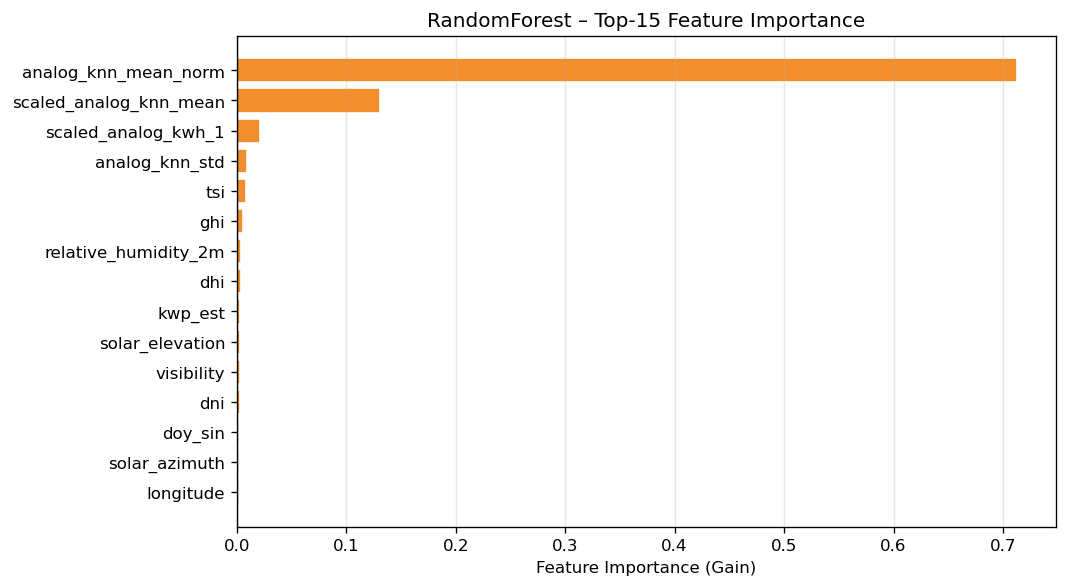

In [7]:
_M = 'RandomForest'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('RandomForest')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Feature Importance (Top 15) ───────────────────────────────────────────
    _fi = _r.get('raw', {}).get('feature_importance')
    if _fi:
        _fi_s = sorted(_fi.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
        _fn = [x[0] for x in _fi_s]; _fv = [x[1] for x in _fi_s]
        if 'RandomForest' == 'Ridge':
            _fc = ['#2ca02c' if v >= 0 else '#d62728' for v in _fv]
            _xlabel = 'Koeffizient'
        else:
            _fc = [PALETTE.get('RandomForest', '#4e79a7')] * len(_fv)
            _xlabel = 'Feature Importance (Gain)'
        fig_fi, ax_fi = plt.subplots(figsize=(9, 5))
        ax_fi.barh(_fn[::-1], _fv[::-1], color=_fc[::-1], edgecolor='white')
        ax_fi.set_xlabel(_xlabel)
        ax_fi.set_title(f'RandomForest – Top-15 Feature Importance')
        ax_fi.axvline(0, color='black', linewidth=0.7)
        ax_fi.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/randomforest_fi.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print('  Feature Importance nicht verfügbar (nicht im JSON gespeichert)')

## LightGBM

Gradient Boosting auf allen Features (State-of-the-art tabellarisch).

=== LightGBM ===
Typ: tree
Trainingszeit: 371.1 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0122,0.0947,0.0387,0.1328,0.7244



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0172,0.1022,0.0502,0.2837,0.7691



Inferenzzeit für 144 Predictions: 0.72 ± 0.03 ms
  = 4.97 µs/Sample | 0.7 ms gesamt


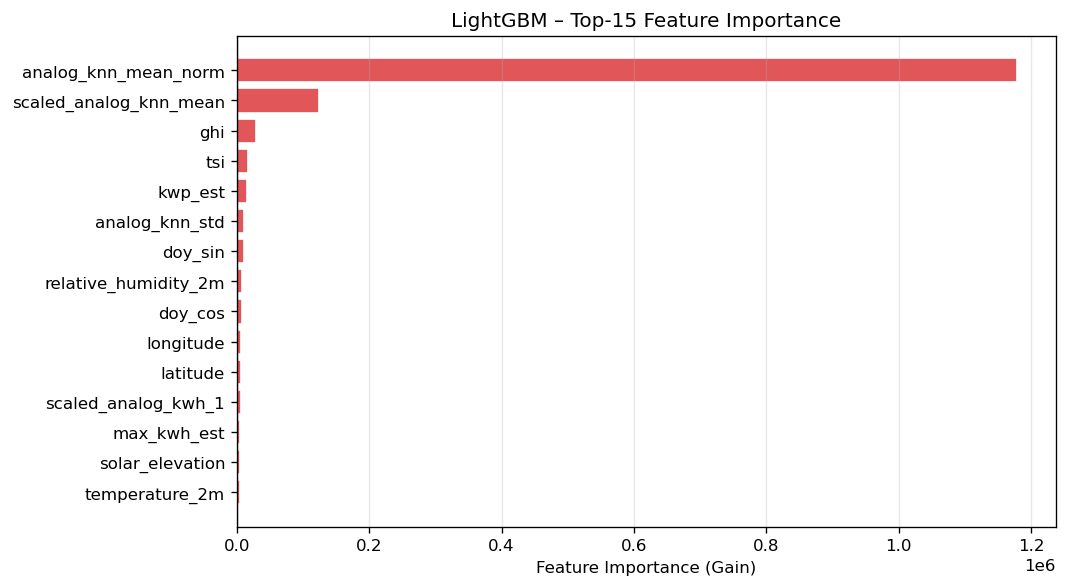

In [8]:
_M = 'LightGBM'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('LightGBM')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Feature Importance (Top 15) ───────────────────────────────────────────
    _fi = _r.get('raw', {}).get('feature_importance')
    if _fi:
        _fi_s = sorted(_fi.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
        _fn = [x[0] for x in _fi_s]; _fv = [x[1] for x in _fi_s]
        if 'LightGBM' == 'Ridge':
            _fc = ['#2ca02c' if v >= 0 else '#d62728' for v in _fv]
            _xlabel = 'Koeffizient'
        else:
            _fc = [PALETTE.get('LightGBM', '#4e79a7')] * len(_fv)
            _xlabel = 'Feature Importance (Gain)'
        fig_fi, ax_fi = plt.subplots(figsize=(9, 5))
        ax_fi.barh(_fn[::-1], _fv[::-1], color=_fc[::-1], edgecolor='white')
        ax_fi.set_xlabel(_xlabel)
        ax_fi.set_title(f'LightGBM – Top-15 Feature Importance')
        ax_fi.axvline(0, color='black', linewidth=0.7)
        ax_fi.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/lightgbm_fi.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print('  Feature Importance nicht verfügbar (nicht im JSON gespeichert)')

## LightGBM_SPT (nur OOS-Vergleich)

LightGBM auf reduziertem SPT-Feature-Set (16 Features). **Im globalen Vergleich werden nur OOS-Metriken verwendet** (trainiert auf anderem Dataset).

=== LightGBM_SPT ===
Typ: tree
Trainingszeit: 20.2 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0281,0.0533,0.0443,0.0764,0.6455



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0347,nan,0.0915,0.3915,0.3375



[Hinweis] LightGBM_SPT wurde auf SPT-Daten (anderem Dataset) trainiert.
          Im globalen Vergleich werden nur OOS-Metriken verwendet.

Inferenzzeit: nicht gemessen


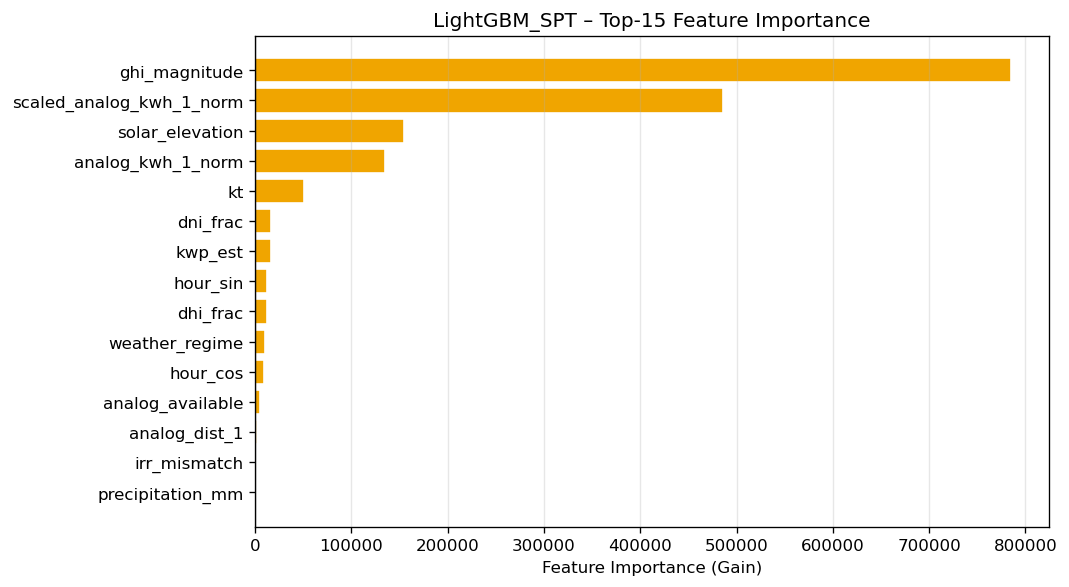

In [9]:
_M = 'LightGBM_SPT'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    print('\n[Hinweis] LightGBM_SPT wurde auf SPT-Daten (anderem Dataset) trainiert.')
    print('          Im globalen Vergleich werden nur OOS-Metriken verwendet.')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('LightGBM_SPT')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Feature Importance (Top 15) ───────────────────────────────────────────
    _fi = _r.get('raw', {}).get('feature_importance')
    if _fi:
        _fi_s = sorted(_fi.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
        _fn = [x[0] for x in _fi_s]; _fv = [x[1] for x in _fi_s]
        if 'LightGBM_SPT' == 'Ridge':
            _fc = ['#2ca02c' if v >= 0 else '#d62728' for v in _fv]
            _xlabel = 'Koeffizient'
        else:
            _fc = [PALETTE.get('LightGBM_SPT', '#4e79a7')] * len(_fv)
            _xlabel = 'Feature Importance (Gain)'
        fig_fi, ax_fi = plt.subplots(figsize=(9, 5))
        ax_fi.barh(_fn[::-1], _fv[::-1], color=_fc[::-1], edgecolor='white')
        ax_fi.set_xlabel(_xlabel)
        ax_fi.set_title(f'LightGBM_SPT – Top-15 Feature Importance')
        ax_fi.axvline(0, color='black', linewidth=0.7)
        ax_fi.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/lightgbm_spt_fi.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print('  Feature Importance nicht verfügbar (nicht im JSON gespeichert)')

## GRU

Gated Recurrent Unit – rekurrentes Netz für Sequenzmodellierung.

=== GRU ===
Typ: rnn
Trainingszeit: 2273.3 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0113,0.0995,0.0423,0.1455,0.6879



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0153,0.0995,0.0501,0.1399,0.7693



Inferenzzeit für 144 Predictions: 357.21 ± 18.91 ms
  = 2480.63 µs/Sample | 357.2 ms gesamt


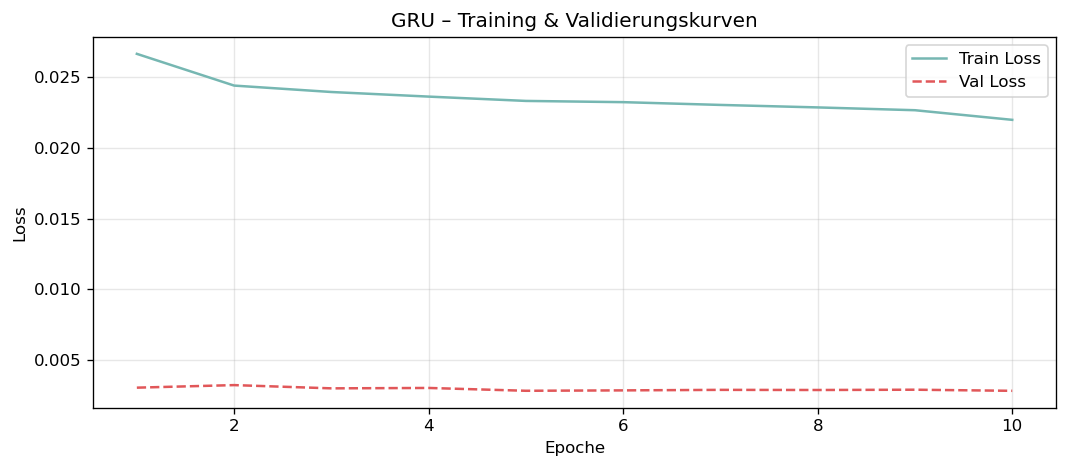

  Best Val Loss: 0.0029 (Epoche 10)

Feature Importance: nicht direkt verfügbar (black-box DL-Modell)


In [10]:
_M = 'GRU'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('GRU')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Training-Kurven ───────────────────────────────────────────────────────
    _tl = _r.get('train_losses', [])
    _vl = _r.get('val_losses', [])
    if _tl and _vl:
        fig, ax = plt.subplots(figsize=(9, 4))
        _ep = range(1, len(_tl)+1)
        ax.plot(_ep, _tl, label='Train Loss', color=PALETTE.get(_M, '#4e79a7'))
        ax.plot(_ep, _vl, label='Val Loss',   color='#e15759', linestyle='--')
        ax.set_xlabel('Epoche'); ax.set_ylabel('Loss')
        ax.set_title(f'{_M} – Training & Validierungskurven')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/{_M.lower().replace("-","_")}_training.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'  Best Val Loss: {min(_vl):.4f} (Epoche {_vl.index(min(_vl))+1})')
    else:
        print('  Keine Trainingskurven verfügbar.')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: nicht direkt verfügbar (black-box DL-Modell)')

## CNN-LSTM

Hybridarchitektur: CNN für lokale Muster + LSTM für Langzeitgedächtnis.

=== CNN-LSTM ===
Typ: rnn
Trainingszeit: 189.6 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0116,0.1015,0.0426,0.1451,0.6841



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0155,0.1016,0.0509,0.1402,0.7624



Inferenzzeit für 144 Predictions: 288.07 ± 4.11 ms
  = 2000.50 µs/Sample | 288.1 ms gesamt


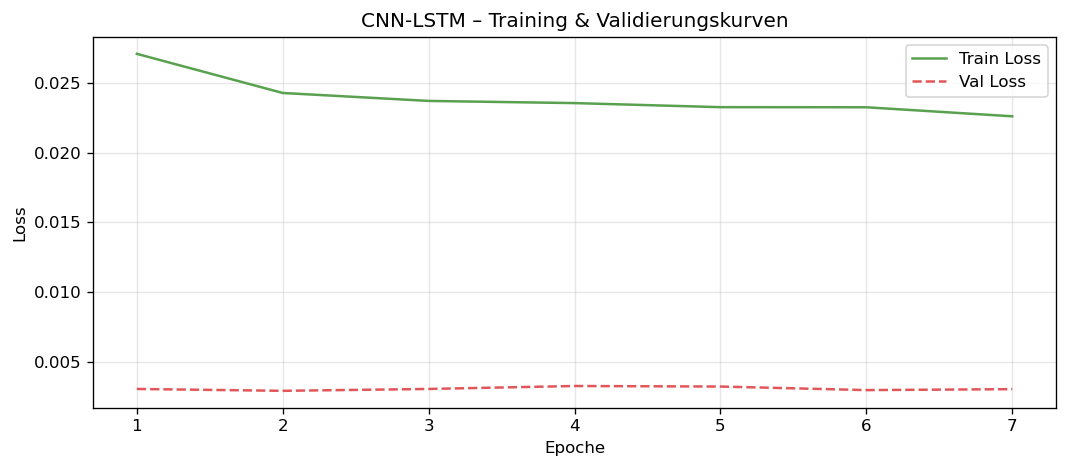

  Best Val Loss: 0.0029 (Epoche 2)

Feature Importance: nicht direkt verfügbar (black-box DL-Modell)


In [11]:
_M = 'CNN-LSTM'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('CNN-LSTM')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Training-Kurven ───────────────────────────────────────────────────────
    _tl = _r.get('train_losses', [])
    _vl = _r.get('val_losses', [])
    if _tl and _vl:
        fig, ax = plt.subplots(figsize=(9, 4))
        _ep = range(1, len(_tl)+1)
        ax.plot(_ep, _tl, label='Train Loss', color=PALETTE.get(_M, '#4e79a7'))
        ax.plot(_ep, _vl, label='Val Loss',   color='#e15759', linestyle='--')
        ax.set_xlabel('Epoche'); ax.set_ylabel('Loss')
        ax.set_title(f'{_M} – Training & Validierungskurven')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/{_M.lower().replace("-","_")}_training.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'  Best Val Loss: {min(_vl):.4f} (Epoche {_vl.index(min(_vl))+1})')
    else:
        print('  Keine Trainingskurven verfügbar.')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: nicht direkt verfügbar (black-box DL-Modell)')

## TSMixer

MLP-Mixer für Zeitreihen ohne Attention-Mechanismus.

=== TSMixer ===
Typ: mlp
Trainingszeit: 256.5 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0115,0.1018,0.0416,0.1438,0.6988



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0156,0.1106,0.0502,0.1479,0.7687



Inferenzzeit für 144 Predictions: 21.69 ± 4.29 ms
  = 150.64 µs/Sample | 21.7 ms gesamt


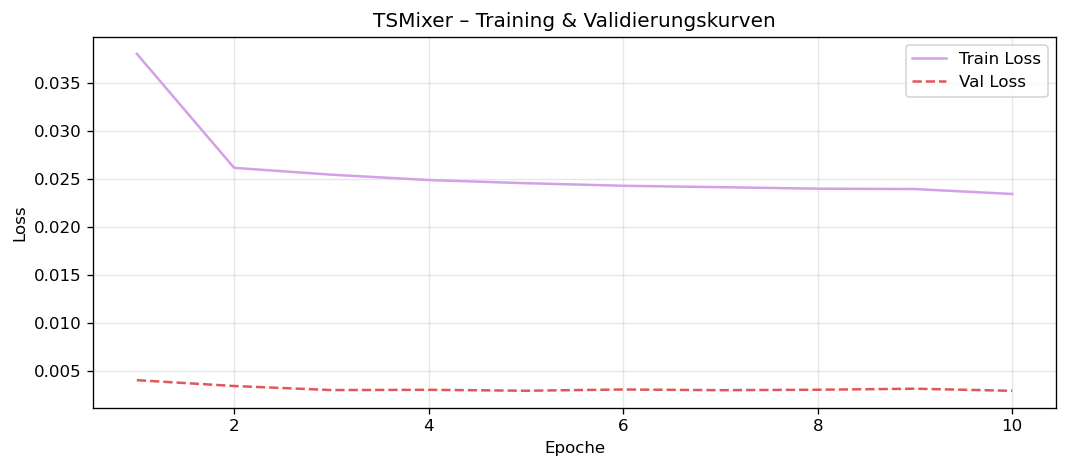

  Best Val Loss: 0.0029 (Epoche 10)

Feature Importance: nicht direkt verfügbar (black-box DL-Modell)


In [12]:
_M = 'TSMixer'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('TSMixer')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Training-Kurven ───────────────────────────────────────────────────────
    _tl = _r.get('train_losses', [])
    _vl = _r.get('val_losses', [])
    if _tl and _vl:
        fig, ax = plt.subplots(figsize=(9, 4))
        _ep = range(1, len(_tl)+1)
        ax.plot(_ep, _tl, label='Train Loss', color=PALETTE.get(_M, '#4e79a7'))
        ax.plot(_ep, _vl, label='Val Loss',   color='#e15759', linestyle='--')
        ax.set_xlabel('Epoche'); ax.set_ylabel('Loss')
        ax.set_title(f'{_M} – Training & Validierungskurven')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/{_M.lower().replace("-","_")}_training.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'  Best Val Loss: {min(_vl):.4f} (Epoche {_vl.index(min(_vl))+1})')
    else:
        print('  Keine Trainingskurven verfügbar.')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: nicht direkt verfügbar (black-box DL-Modell)')

## iTransformer

Inverted Transformer: Attention über Feature-Dimensionen (slen=168).

=== iTransformer ===
Typ: transformer
Trainingszeit: 147.3 s

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0115,0.0965,0.0415,0.1379,0.6892



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0161,0.0962,0.0513,0.1332,0.7567



Inferenzzeit für 144 Predictions: 8.69 ± 0.57 ms
  = 60.34 µs/Sample | 8.7 ms gesamt


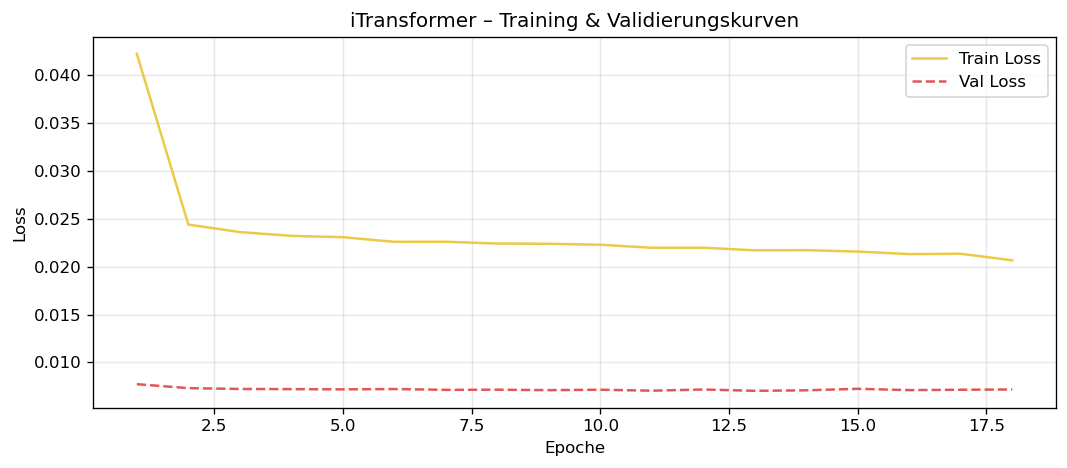

  Best Val Loss: 0.0070 (Epoche 13)

Feature Importance: nicht direkt verfügbar (black-box DL-Modell)


In [13]:
_M = 'iTransformer'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('iTransformer')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Training-Kurven ───────────────────────────────────────────────────────
    _tl = _r.get('train_losses', [])
    _vl = _r.get('val_losses', [])
    if _tl and _vl:
        fig, ax = plt.subplots(figsize=(9, 4))
        _ep = range(1, len(_tl)+1)
        ax.plot(_ep, _tl, label='Train Loss', color=PALETTE.get(_M, '#4e79a7'))
        ax.plot(_ep, _vl, label='Val Loss',   color='#e15759', linestyle='--')
        ax.set_xlabel('Epoche'); ax.set_ylabel('Loss')
        ax.set_title(f'{_M} – Training & Validierungskurven')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'modelresults/{_M.lower().replace("-","_")}_training.png', bbox_inches='tight', dpi=150)
        plt.show()
        print(f'  Best Val Loss: {min(_vl):.4f} (Epoche {_vl.index(min(_vl))+1})')
    else:
        print('  Keine Trainingskurven verfügbar.')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: nicht direkt verfügbar (black-box DL-Modell)')

## Chronos

Foundation Model (Amazon Chronos T5-tiny), zero-shot, kein Fine-Tuning.

In [14]:
_M = 'Chronos'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms_med, _ms_std = inference_ms.get('Chronos', (1332.89, 93.57))
    print(f'\nInferenzzeit für {BATCH} Predictions: {_ms_med:.2f} ± {_ms_std:.2f} ms')
    print(f'  = {_ms_med/BATCH*1000:.2f} µs/Sample | {_ms_med:.1f} ms gesamt (vorher gemessen)')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: nicht verfügbar (zero-shot Foundation Model)')

=== Chronos ===
Typ: foundation

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.0547,0.2705,0.1269,0.3144,-0.5116



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0466,0.2874,0.1234,0.3423,-0.4229



Inferenzzeit für 144 Predictions: 1332.89 ± 93.57 ms
  = 9256.18 µs/Sample | 1332.9 ms gesamt (vorher gemessen)

Feature Importance: nicht verfügbar (zero-shot Foundation Model)


## Analog KNN Baseline

Historische Analogmethode: nächste Nachbarn im Feature-Raum.

In [15]:
_M = 'Analog KNN'
_r = RESULTS.get(_M, {})
if not _r:
    print(f'{_M} nicht geladen.')
else:
    print(f'=== {_M} ===')
    print(f'Typ: {_r.get("type","?")}')
    if _r.get('train_time'):
        print(f'Trainingszeit: {_r["train_time"]:.1f} s')

    # ── Test-Set Metriken ─────────────────────────────────────────────────────
    _metrics_test = {
        'MAE':   _r['mae'],
        'wMAE':  _r['wmae'],
        'RMSE':  _r['rmse'],
        'wRMSE': _r['wrmse'],
        'R²':    _r['r2'],
    }
    print('\nTest-Set Metriken:')
    _df_t = pd.DataFrame([_metrics_test])
    display(_df_t.style.format({c: '{:.4f}' for c in _df_t.columns}).set_caption(f'{_M} – Test-Set'))

    # ── OOS Metriken ──────────────────────────────────────────────────────────
    _oos = _r.get('oos', {})
    if _oos:
        _metrics_oos = {
            'OOS MAE':   _oos.get('mae', float('nan')),
            'OOS wMAE':  _oos.get('wmae', float('nan')),
            'OOS RMSE':  _oos.get('rmse', float('nan')),
            'OOS wRMSE': _oos.get('wrmse', float('nan')),
            'OOS R²':    _oos.get('r2', float('nan')),
        }
        print('\nOOS Metriken:')
        _df_oos = pd.DataFrame([_metrics_oos])
        display(_df_oos.style.format({c: '{:.4f}' for c in _df_oos.columns}).set_caption(f'{_M} – OOS'))
    else:
        print('\nOOS Metriken: –')
    # ── Inferenzzeit ──────────────────────────────────────────────────────────
    _ms = inference_ms.get('Analog KNN')
    if _ms:
        print(f'\nInferenzzeit für {BATCH} Predictions: {_ms[0]:.2f} ± {_ms[1]:.2f} ms')
        print(f'  = {_ms[0]/BATCH*1000:.2f} µs/Sample | {_ms[0]:.1f} ms gesamt')
    else:
        print('\nInferenzzeit: nicht gemessen')
    # ── Feature Importance ────────────────────────────────────────────────────
    print('\nFeature Importance: scaled_analog_knn_mean (einziges genutztes Feature)')

=== Analog KNN ===
Typ: baseline

Test-Set Metriken:


,MAE,wMAE,RMSE,wRMSE,R²
0,0.1340,0.7408,0.3752,0.9572,-12.8236



OOS Metriken:


,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²
0,0.0706,0.6146,0.2426,0.7743,-8.6323



Inferenzzeit für 144 Predictions: 0.48 ± 0.01 ms
  = 3.34 µs/Sample | 0.5 ms gesamt

Feature Importance: scaled_analog_knn_mean (einziges genutztes Feature)


## Vergleich – Test-Set Metriken (LightGBM_SPT als separates OOS-Modell)

Alle Modelle im direkten Vergleich. **LightGBM_SPT** wird mit OOS-Metriken gezeigt (trainiert auf anderem Dataset). **Analog KNN** dient als Baseline.

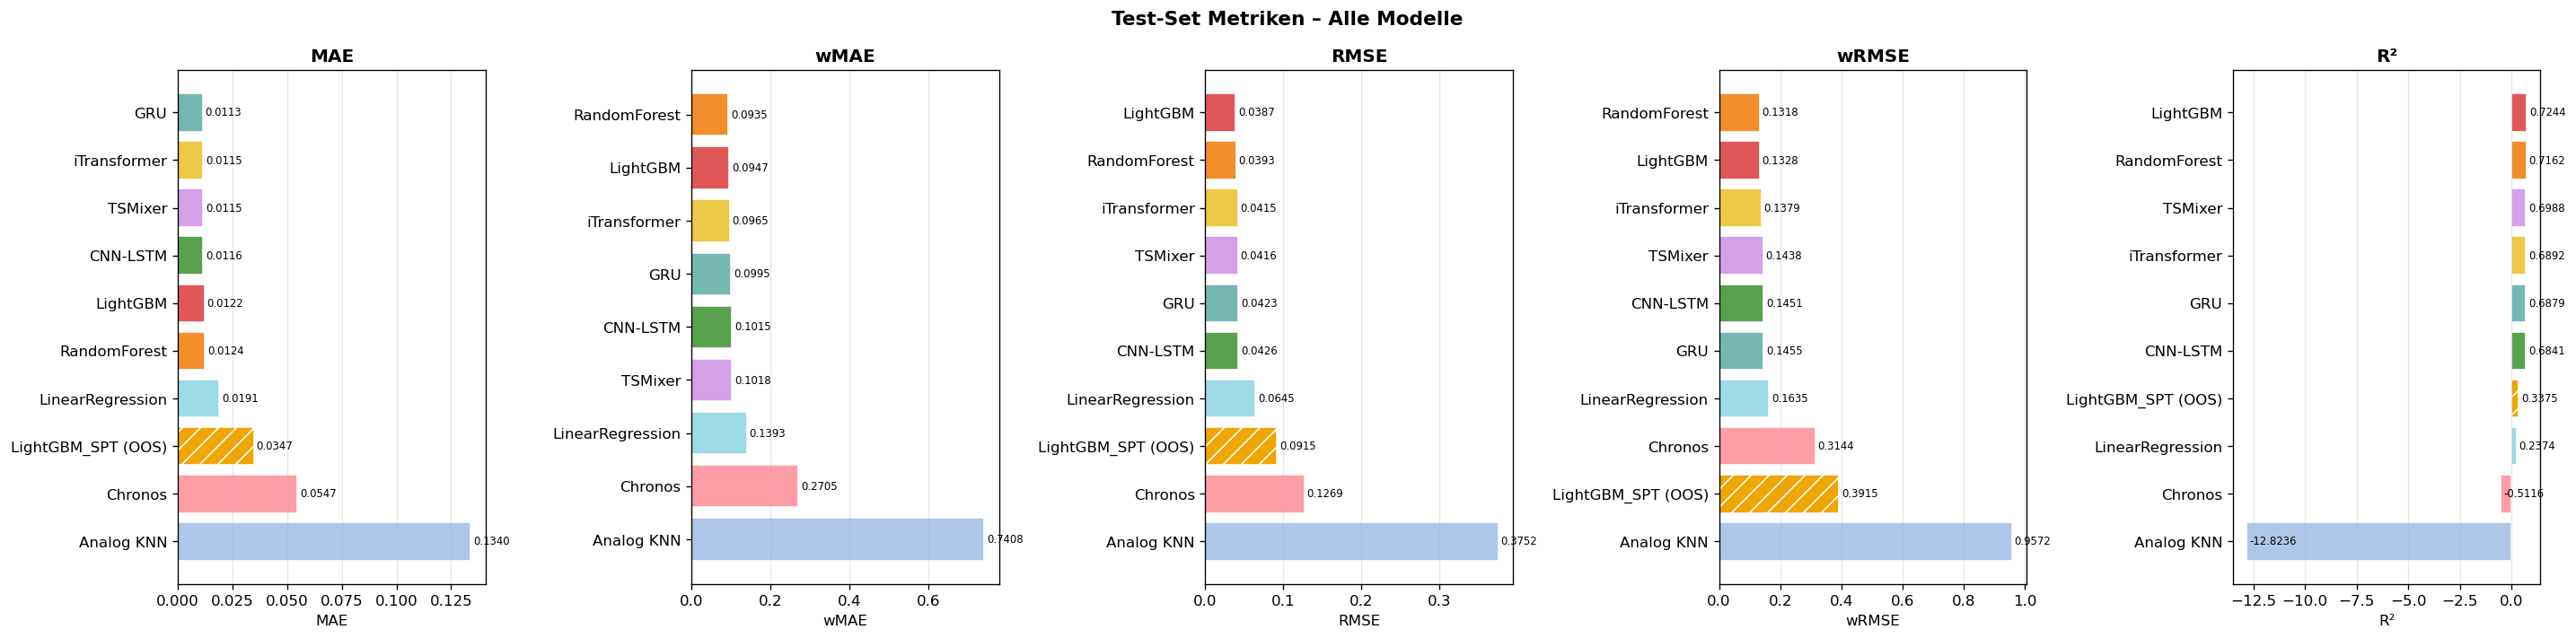

LightGBM_SPT (schraffiert) zeigt OOS-Metriken (trainiert auf SPT-Dataset).


In [16]:
# ── Test-Set Metrik-Vergleich (5 Bar Charts) ─────────────────────────────────
# Models for comparison (excluding LightGBM_SPT from main comparison)
_cmp_models = [n for n in ['LinearRegression','RandomForest','LightGBM','LightGBM_SPT',
                             'GRU','CNN-LSTM','TSMixer','iTransformer','Chronos','Analog KNN']
               if n in RESULTS]

metrics_list = [('MAE','mae'), ('wMAE','wmae'), ('RMSE','rmse'), ('wRMSE','wrmse'), ('R²','r2')]

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
fig.suptitle('Test-Set Metriken – Alle Modelle', fontsize=13, fontweight='bold')

for ax, (metric_label, metric_key) in zip(axes, metrics_list):
    _vals = {}
    for n in _cmp_models:
        if n == 'LightGBM_SPT':
            # Use OOS metrics for LightGBM_SPT
            _oos_v = RESULTS[n].get('oos', {}).get(metric_key, float('nan'))
            if not np.isnan(_oos_v):
                _vals['LightGBM_SPT (OOS)'] = _oos_v
        elif metric_key in RESULTS[n]:
            _vals[n] = RESULTS[n][metric_key]

    _ascending = metric_label != 'R²'
    _sorted_names = sorted(_vals, key=lambda x: _vals[x], reverse=not _ascending)
    _v = [_vals[n] for n in _sorted_names]
    _c = [PALETTE.get(n.replace(' (OOS)',''), '#aaaaaa') for n in _sorted_names]
    _hatch = ['//' if '(OOS)' in n else '' for n in _sorted_names]
    bars = ax.barh(_sorted_names, _v, color=_c, edgecolor='white', hatch=_hatch)
    ax.set_title(metric_label, fontweight='bold')
    ax.set_xlabel(metric_label)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    _rng = max(_v) - min(_v) if len(_v) > 1 else max(_v) if _v else 1.0
    for bar, v in zip(bars, _v):
        ax.text(bar.get_width() + _rng*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('modelresults/metric_comparison_test.png', bbox_inches='tight', dpi=150)
plt.show()
print('LightGBM_SPT (schraffiert) zeigt OOS-Metriken (trainiert auf SPT-Dataset).')

## Vergleich – OOS Generalisierung

Out-of-Sample Metriken für alle Modelle mit OOS-Daten. Zeigt Generalisierungsfähigkeit auf unsichtbaren Datensätzen (100 OOS Spots).

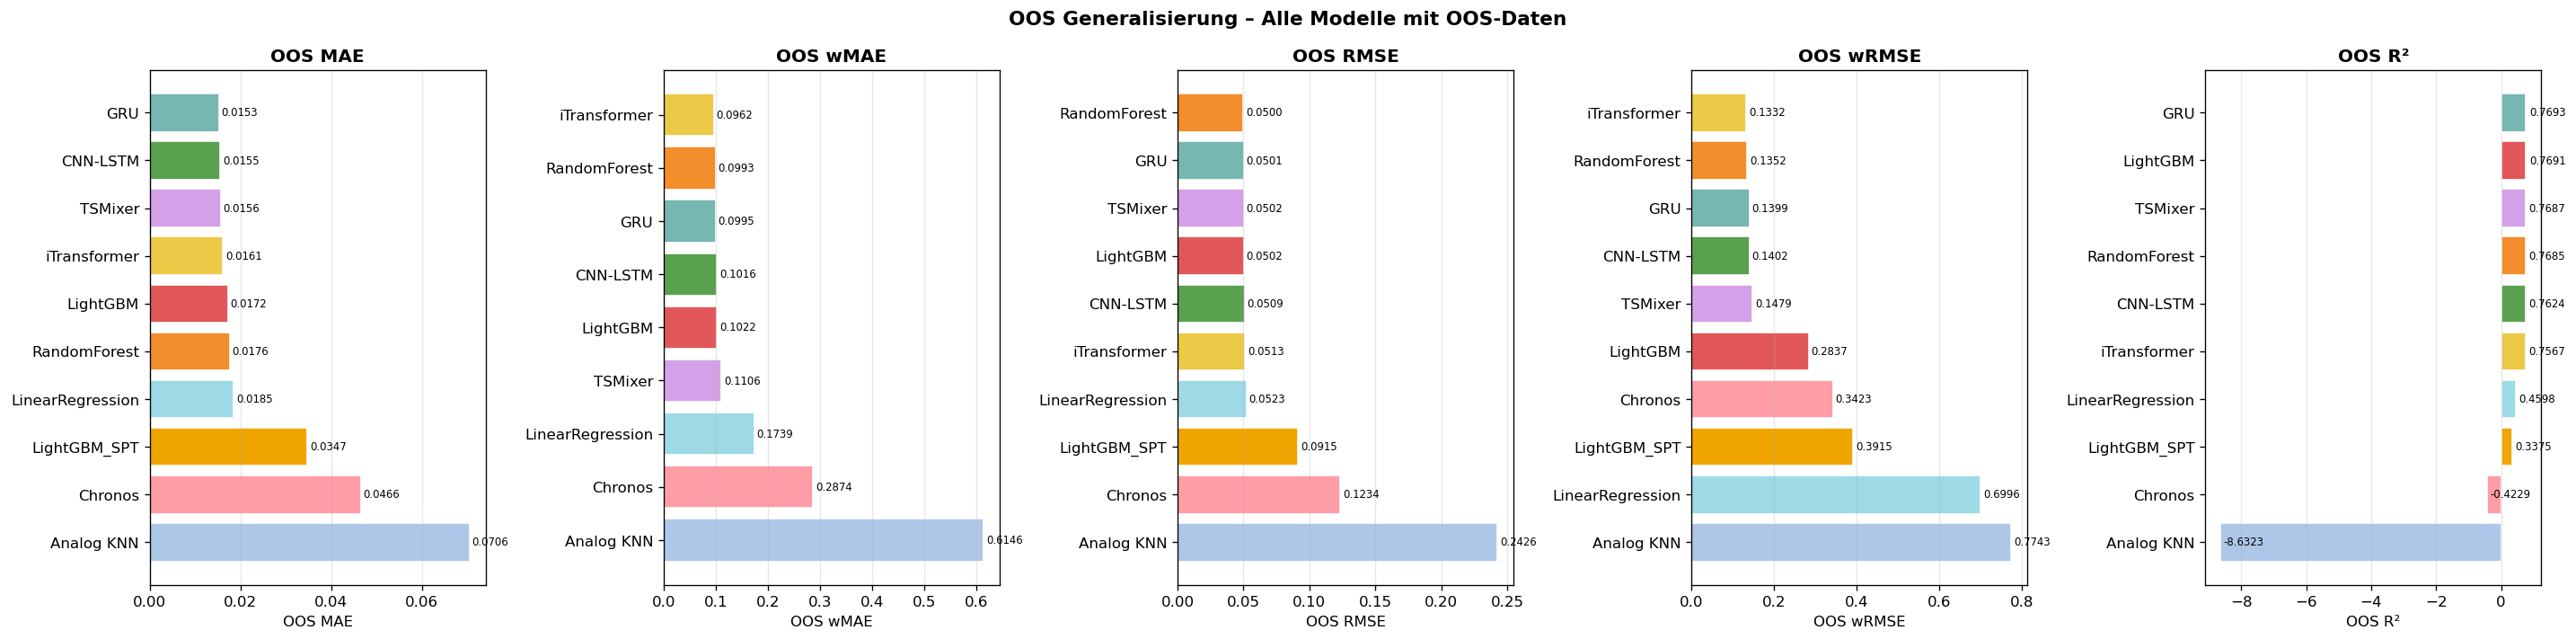

In [17]:
# ── OOS Generalisierung ──────────────────────────────────────────────────────
_oos_models = [n for n in ['LinearRegression','RandomForest','LightGBM','LightGBM_SPT',
                             'GRU','CNN-LSTM','TSMixer','iTransformer','Chronos','Analog KNN']
               if n in RESULTS and RESULTS[n].get('oos')]

if not _oos_models:
    print('Keine OOS-Daten verfügbar.')
else:
    oos_metrics = [('OOS MAE','mae'), ('OOS wMAE','wmae'), ('OOS RMSE','rmse'), ('OOS wRMSE','wrmse'), ('OOS R²','r2')]
    fig, axes = plt.subplots(1, 5, figsize=(24, 6))
    fig.suptitle('OOS Generalisierung – Alle Modelle mit OOS-Daten', fontsize=13, fontweight='bold')

    for ax, (metric_label, metric_key) in zip(axes, oos_metrics):
        _vals = {n: RESULTS[n]['oos'].get(metric_key, float('nan'))
                 for n in _oos_models if not np.isnan(RESULTS[n]['oos'].get(metric_key, float('nan')))}
        _ascending = metric_label != 'OOS R²'
        _sorted_names = sorted(_vals, key=lambda x: _vals[x], reverse=not _ascending)
        _v = [_vals[n] for n in _sorted_names]
        _c = [PALETTE.get(n, '#aaaaaa') for n in _sorted_names]
        bars = ax.barh(_sorted_names, _v, color=_c, edgecolor='white')
        ax.set_title(metric_label, fontweight='bold')
        ax.set_xlabel(metric_label)
        ax.invert_yaxis()
        ax.grid(True, axis='x', alpha=0.3)
        _rng = max(_v) - min(_v) if len(_v) > 1 else (max(_v) if _v else 1.0)
        for bar, v in zip(bars, _v):
            ax.text(bar.get_width() + _rng*0.01, bar.get_y() + bar.get_height()/2,
                    f'{v:.4f}', va='center', fontsize=7)

    plt.tight_layout()
    plt.savefig('modelresults/metric_comparison_oos.png', bbox_inches='tight', dpi=150)
    plt.show()

## Inferenzzeit

CPU-Inferenzzeit für **144 Predictions** (= 36h Prognose à 15min).
Gemessen auf Apple M2-Chip (16 GB RAM), Median über 10 Runs.

Zusätzlich: geschätzte **Stromkosten** bei 65W CPU-Last und 37 ct/kWh für 1 Mio Predictions.

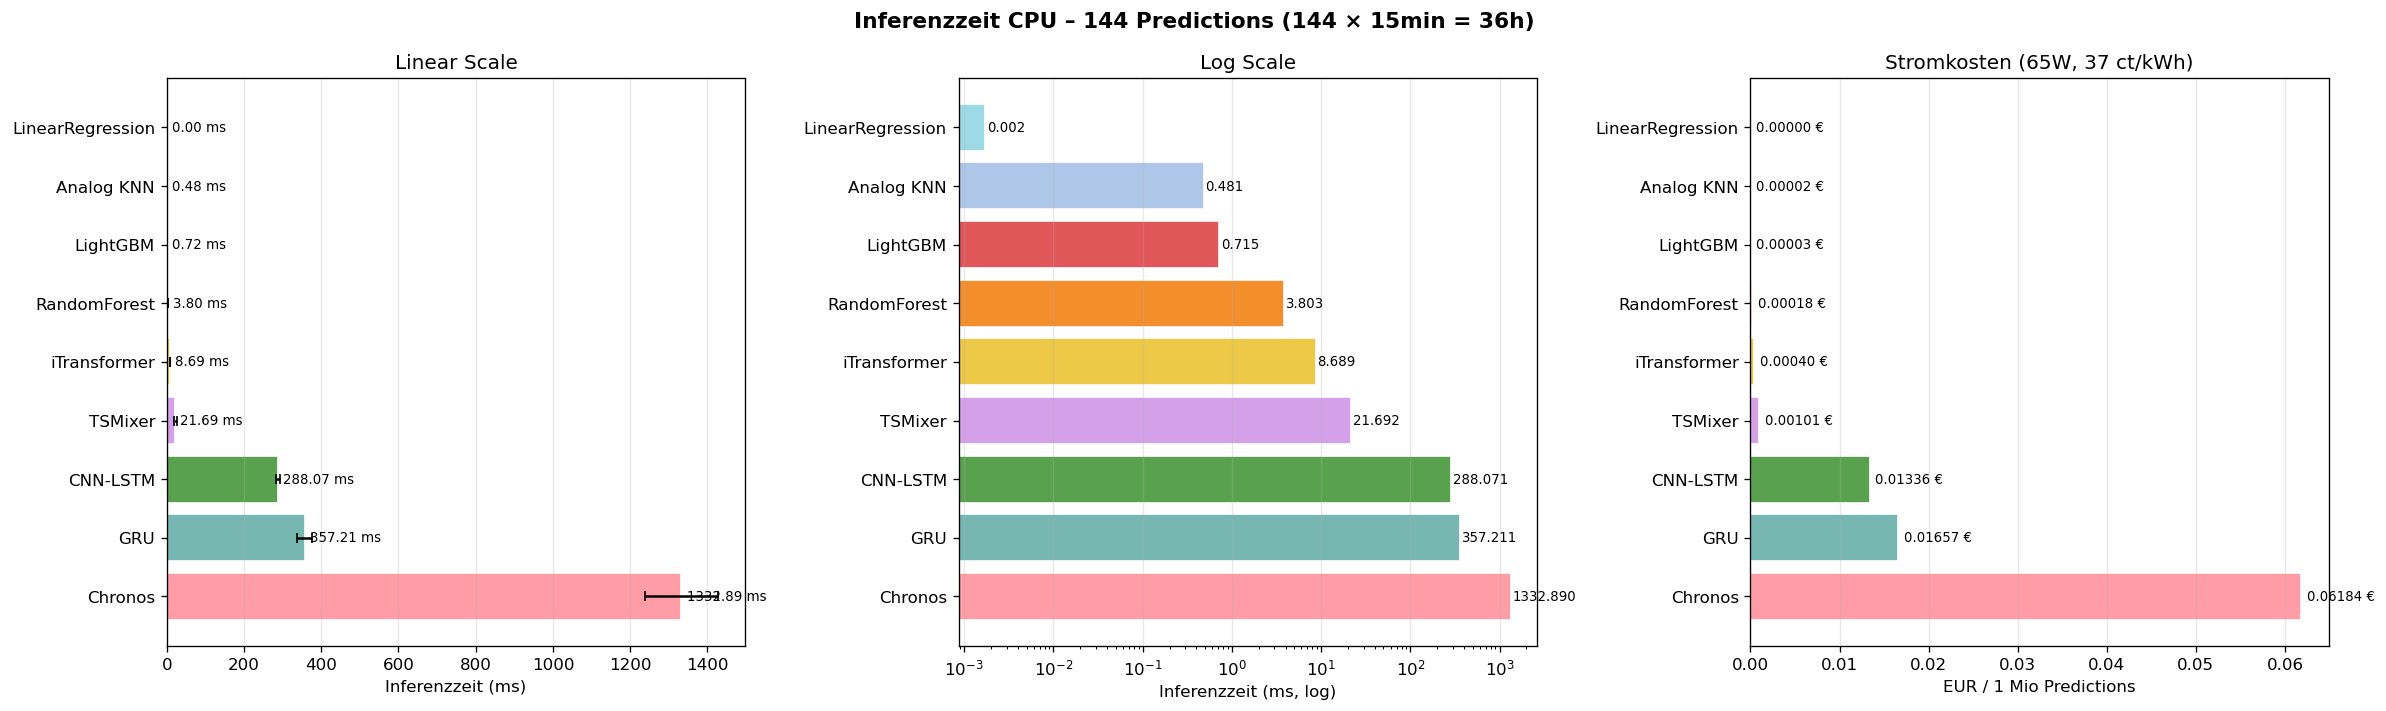


Modell                ms / 144   µs/Sample   EUR / 1 Mio
------------------------------------------------------------
LinearRegression       0.002 ms      0.01 µs     0.00000 EUR
Analog KNN             0.481 ms      3.34 µs     0.00002 EUR
LightGBM               0.715 ms      4.97 µs     0.00003 EUR
RandomForest           3.803 ms     26.41 µs     0.00018 EUR
iTransformer           8.689 ms     60.34 µs     0.00040 EUR
TSMixer               21.692 ms    150.64 µs     0.00101 EUR
CNN-LSTM             288.071 ms   2000.50 µs     0.01336 EUR
GRU                  357.211 ms   2480.63 µs     0.01657 EUR
Chronos             1332.890 ms   9256.18 µs     0.06184 EUR


In [18]:
# ── Inferenzzeit + Stromkosten Plots ─────────────────────────────────────────
_PLOT_MODELS = ['LinearRegression','RandomForest','LightGBM',
                'GRU','CNN-LSTM','TSMixer','iTransformer','Chronos','Analog KNN']
_inf_data = [(n, inference_ms[n][0], inference_ms[n][1])
             for n in _PLOT_MODELS if n in inference_ms]
_inf_sorted = sorted(_inf_data, key=lambda x: x[1])
_in = [x[0] for x in _inf_sorted]
_iv = [x[1] for x in _inf_sorted]
_ie = [x[2] for x in _inf_sorted]
_ic = [PALETTE.get(n,'#aaaaaa') for n in _in]

# Stromkosten pro 1 Mio Predictions
_CPU_W = 65; _PRICE_EUR = 0.37
def _cost_per_M(ms): return (ms / BATCH) * 1_000_000 / 3_600_000 * (_CPU_W/1000) * _PRICE_EUR
_costs = [_cost_per_M(v) for v in _iv]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Inferenzzeit CPU – {BATCH} Predictions (144 × 15min = 36h)',
             fontsize=13, fontweight='bold')

# Linear scale
bars = axes[0].barh(_in, _iv, xerr=_ie, color=_ic, edgecolor='white', capsize=3)
axes[0].set_xlabel('Inferenzzeit (ms)')
axes[0].set_title('Linear Scale')
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', alpha=0.3)
for bar, v in zip(bars, _iv):
    axes[0].text(bar.get_width() + max(_iv)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f} ms', va='center', fontsize=8)

# Log scale
bars2 = axes[1].barh(_in, _iv, color=_ic, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('Inferenzzeit (ms, log)')
axes[1].set_title('Log Scale')
axes[1].invert_yaxis()
axes[1].grid(True, axis='x', alpha=0.3)
for bar, v in zip(bars2, _iv):
    axes[1].text(bar.get_width()*1.05, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=8)

# Stromkosten
bars3 = axes[2].barh(_in, _costs, color=_ic, edgecolor='white')
axes[2].set_xlabel('EUR / 1 Mio Predictions')
axes[2].set_title('Stromkosten (65W, 37 ct/kWh)')
axes[2].invert_yaxis()
axes[2].grid(True, axis='x', alpha=0.3)
for bar, v in zip(bars3, _costs):
    axes[2].text(bar.get_width() + max(_costs)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.5f} €', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('modelresults/inference_time.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n{"Modell":18s}  {"ms / 144":>10s}  {"µs/Sample":>10s}  {"EUR / 1 Mio":>12s}')
print('-' * 60)
for n, v, e in _inf_sorted:
    cost = _cost_per_M(v)
    print(f'{n:18s}  {v:8.3f} ms  {v/BATCH*1000:8.2f} µs  {cost:10.5f} EUR')

## UMBRA Batteriesimulation

Vergleich des mittleren Netzverbrauchs (kWh/Tag) je Modell. **Niedrigerer Wert = bessere Prognosequalität für Batteriebetrieb.** Ground Truth dient als Referenz.

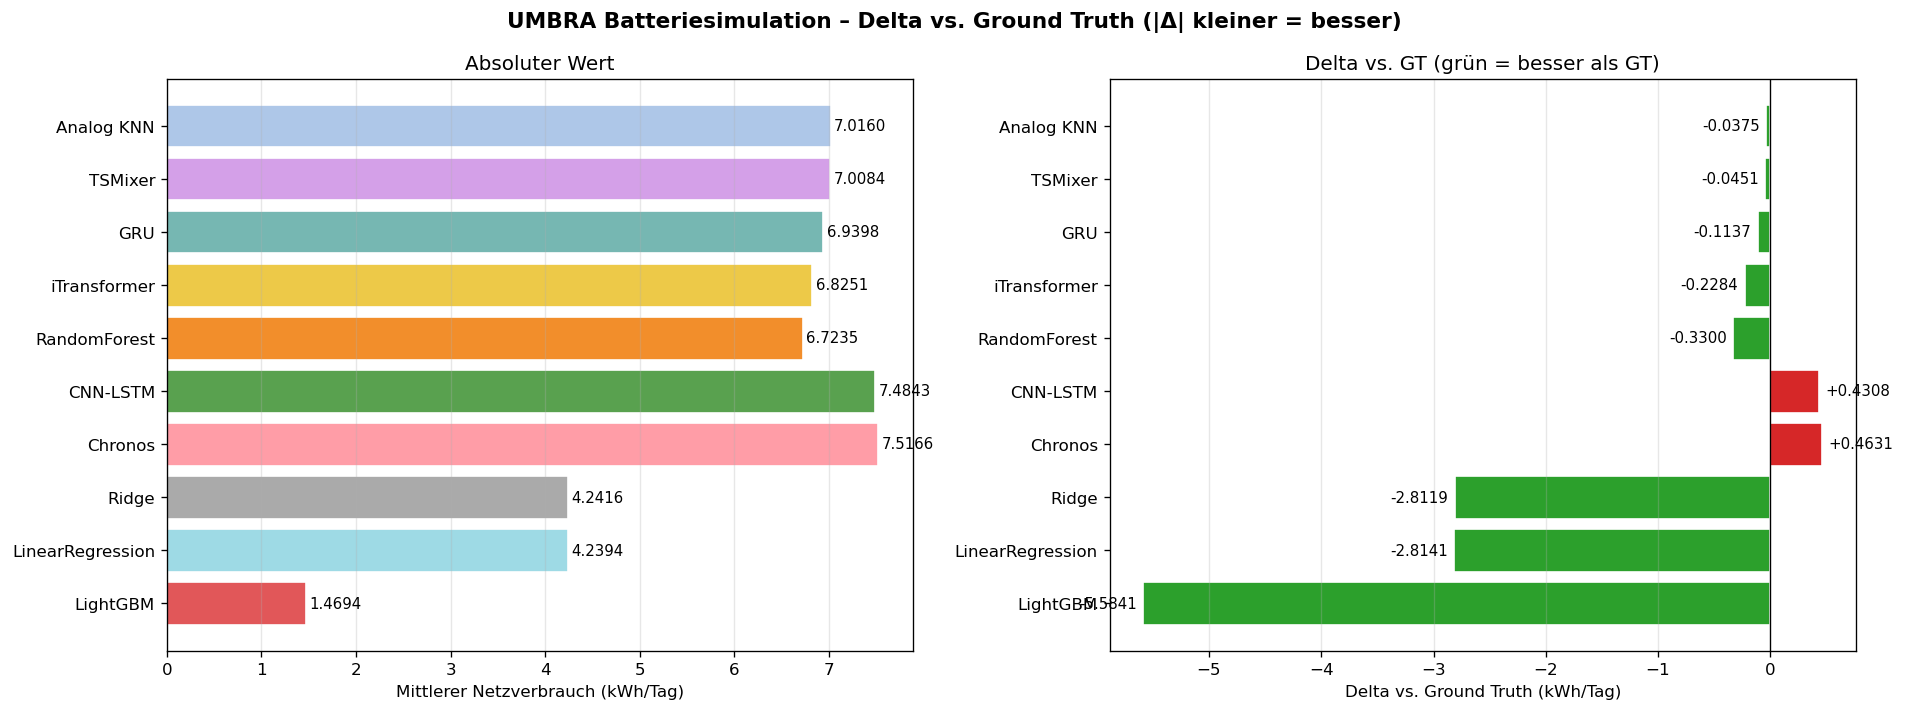

,Modell,UMBRA mean (kWh/Tag),Delta vs. GT
0,Analog KNN,7.0160,-0.0375
1,TSMixer,7.0084,-0.0451
2,GRU,6.9398,-0.1137
3,iTransformer,6.8251,-0.2284
4,RandomForest,6.7235,-0.3300
5,CNN-LSTM,7.4843,+0.4308
6,Chronos,7.5166,+0.4631
7,Ridge,4.2416,-2.8119
8,LinearRegression,4.2394,-2.8141
9,LightGBM,1.4694,-5.5841


In [19]:
# ── UMBRA Ergebnisse darstellen ──────────────────────────────────────────────
if not umbra_results:
    print('Keine UMBRA-Ergebnisse verfügbar (UMBRA nicht installiert oder Simulation nicht gelaufen).')
else:
    _um_sorted = sorted(umbra_results.items(), key=lambda x: abs(x[1]['delta']))
    _um_names  = [x[0] for x in _um_sorted]
    _um_means  = [x[1]['mean'] for x in _um_sorted]
    _um_deltas = [x[1]['delta'] for x in _um_sorted]
    _um_colors = [PALETTE.get(n,'#aaaaaa') for n in _um_names]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('UMBRA Batteriesimulation – Delta vs. Ground Truth (|Δ| kleiner = besser)', fontsize=13, fontweight='bold')

    # Absolute values
    bars = axes[0].barh(_um_names, _um_means, color=_um_colors, edgecolor='white')
    axes[0].set_xlabel('Mittlerer Netzverbrauch (kWh/Tag)')
    axes[0].set_title('Absoluter Wert')
    axes[0].invert_yaxis()
    axes[0].grid(True, axis='x', alpha=0.3)
    for bar, v in zip(bars, _um_means):
        axes[0].text(bar.get_width()+max(_um_means)*0.005, bar.get_y()+bar.get_height()/2,
                     f'{v:.4f}', va='center', fontsize=9)

    # Delta vs GT
    _dc = ['#2ca02c' if d <= 0 else '#d62728' for d in _um_deltas]
    bars2 = axes[1].barh(_um_names, _um_deltas, color=_dc, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Delta vs. Ground Truth (kWh/Tag)')
    axes[1].set_title('Delta vs. GT (grün = besser als GT)')
    axes[1].invert_yaxis()
    axes[1].grid(True, axis='x', alpha=0.3)
    _dr = max(abs(d) for d in _um_deltas) if _um_deltas else 1.0
    for bar, v in zip(bars2, _um_deltas):
        axes[1].text(bar.get_width()+_dr*0.01 if v >= 0 else bar.get_width()-_dr*0.01,
                     bar.get_y()+bar.get_height()/2,
                     f'{v:+.4f}', va='center', fontsize=9,
                     ha='left' if v >= 0 else 'right')

    plt.tight_layout()
    plt.savefig('modelresults/umbra_results.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Table
    _df_umbra_tbl = pd.DataFrame([{'Modell': n, 'UMBRA mean (kWh/Tag)': umbra_results[n]['mean'],
                                    'Delta vs. GT': umbra_results[n]['delta']}
                                   for n in _um_names])
    display(_df_umbra_tbl.style
            .format({'UMBRA mean (kWh/Tag)': '{:.4f}', 'Delta vs. GT': '{:+.4f}'})
            .background_gradient(subset=['UMBRA mean (kWh/Tag)'], cmap='RdYlGn_r')
            .set_caption('UMBRA Ergebnisse – sortiert nach |Delta| (aufsteigend, naeher an GT = besser)'))

## MLFlow Logging

Loggt alle Modellmetriken in MLFlow für spätere Nachverfolgung.

In [20]:
# ── MLFlow Logging ───────────────────────────────────────────────────────────
import os

os.environ['MLFLOW_TRACKING_URI']      = 'http://mlflow.cluster.spotmyenergy.systems'
os.environ['MLFLOW_TRACKING_USERNAME'] = 'spot-adm'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'M2nJ96bZRHCrkAuCs!GXv@j-6Fffz_aZvt@s2KQGo6Vk82A4aMiKk7W'

try:
    mlflow.set_tracking_uri('http://mlflow.cluster.spotmyenergy.systems')
    mlflow.set_experiment('BSc_PV_Forecasting_Comparison')

    for name, r in RESULTS.items():
        with mlflow.start_run(run_name=name):
            mlflow.log_param('model_type', r.get('type', '?'))
            mlflow.log_metric('mae',   r['mae'])
            mlflow.log_metric('rmse',  r['rmse'])
            mlflow.log_metric('r2',    r['r2'])
            mlflow.log_metric('wrmse', r['wrmse'])
            mlflow.log_metric('wmae',  r['wmae'])
            oos = r.get('oos', {})
            if oos.get('mae'):   mlflow.log_metric('oos_mae',   oos['mae'])
            if oos.get('rmse'):  mlflow.log_metric('oos_rmse',  oos['rmse'])
            if oos.get('r2'):    mlflow.log_metric('oos_r2',    oos['r2'])
            if oos.get('wmae'):  mlflow.log_metric('oos_wmae',  oos['wmae'])
            if oos.get('wrmse'): mlflow.log_metric('oos_wrmse', oos['wrmse'])
            ms = inference_ms.get(name)
            if ms: mlflow.log_metric('inference_ms', ms[0])
            if name in umbra_results:
                mlflow.log_metric('umbra_grid_charge_mean', umbra_results[name]['mean'])
                mlflow.log_metric('umbra_delta_vs_gt',      umbra_results[name]['delta'])
            if r.get('train_time'):
                mlflow.log_metric('train_time_s', r['train_time'])
            fi = r.get('raw', {}).get('feature_importance')
            if fi:
                for feat, val in fi.items():
                    try: mlflow.log_metric(f'fi_{feat}', float(val))
                    except: pass
        print(f'  [OK] {name} geloggt')

    print(f'\nMLFlow Logging abgeschlossen: {len(RESULTS)} Modelle -> BSc_PV_Forecasting_Comparison')
except Exception as e:
    print(f'MLFlow Logging fehlgeschlagen: {e}')
    print('Server möglicherweise nicht erreichbar – Ergebnisse nur lokal verfügbar.')

🏃 View run LinearRegression at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4/runs/40cda02dacef4e54abf7c29ba48bd304
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4


  [OK] LinearRegression geloggt


🏃 View run RandomForest at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4/runs/5befc6f8accc4f8da12f3194f05dc84f
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4


  [OK] RandomForest geloggt


🏃 View run LightGBM at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4/runs/243eacc6d85f42a287bc78293b322aab
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4


...

  [OK] iTransformer geloggt


🏃 View run Chronos at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4/runs/cfce53b4767d44b88c4c4414abf69cba
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4


  [OK] Chronos geloggt


🏃 View run Analog KNN at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4/runs/167402d14dae4889b096df9a62b9038d
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/4


  [OK] Analog KNN geloggt

MLFlow Logging abgeschlossen: 10 Modelle -> BSc_PV_Forecasting_Comparison


## Gesamtvergleich – Finale Rangliste

Alle Modelle mit vollständigen Metriken.
**Sortierung:** OOS wMAE aufsteigend (kleiner = besser = generalisiert besser auf ungesehene Spots).

In [21]:
# ── Finale Rangliste – sortiert nach OOS wMAE ────────────────────────────────
_FINAL_MODELS = [n for n in ['LinearRegression','RandomForest','LightGBM',
                              'GRU','CNN-LSTM','TSMixer','iTransformer','Chronos','Analog KNN']
                 if n in RESULTS]

rows = []
for n in _FINAL_MODELS:
    _r   = RESULTS[n]
    _oos = _r.get('oos', {})
    _inf = inference_ms.get(n, (float('nan'), float('nan')))
    _umb = umbra_results.get(n, {})

    _CPU_W = 65; _PRICE_EUR = 0.37
    _cost = (_inf[0] / BATCH) * 1_000_000 / 3_600_000 * (_CPU_W/1000) * _PRICE_EUR

    rows.append({
        'Modell':         n,
        'Test wMAE':      _r.get('wmae', float('nan')),
        'Test wRMSE':     _r.get('wrmse', float('nan')),
        'Test R²':        _r.get('r2', float('nan')),
        'OOS wMAE':       _oos.get('wmae', float('nan')),
        'OOS wRMSE':      _oos.get('wrmse', float('nan')),
        'OOS R²':         _oos.get('r2', float('nan')),
        'Inf ms/144':     _inf[0],
        'EUR/1M Pred':    _cost,
        'UMBRA Δ':        _umb.get('delta', float('nan')),
        'Train s':        _r.get('train_time', float('nan')),
    })

df_final = (pd.DataFrame(rows)
            .sort_values('OOS wMAE', ascending=True)
            .reset_index(drop=True))
df_final.index = df_final.index + 1  # Rang 1 = bestes Modell

# Formatiertes Display
_fmt = {
    'Test wMAE':   '{:.4f}', 'Test wRMSE': '{:.4f}', 'Test R²':    '{:.4f}',
    'OOS wMAE':    '{:.4f}', 'OOS wRMSE':  '{:.4f}', 'OOS R²':     '{:.4f}',
    'Inf ms/144':  '{:.2f}', 'EUR/1M Pred':'{:.5f}',
    'UMBRA Δ':     '{:.3f}', 'Train s':    '{:.1f}',
}

display(df_final.style
        .format({c: f for c, f in _fmt.items() if c in df_final.columns})
        .set_caption('Finale Modellrangliste – sortiert nach OOS wMAE (Rang 1 = bestes Modell)'))

# Speichern als CSV
df_final.to_csv('modelresults/model_comparison_full.csv', index=True)
print(f'\nRangliste gespeichert → modelresults/model_comparison_full.csv')
print(f'Bestes Modell (OOS wMAE): {df_final.iloc[0]["Modell"]}  ({df_final.iloc[0]["OOS wMAE"]:.4f})')

,Modell,Test wMAE,Test wRMSE,Test R²,OOS wMAE,OOS wRMSE,OOS R²,Inf ms/144,EUR/1M Pred,UMBRA Δ,Train s
1,iTransformer,0.0965,0.1379,0.6892,0.0962,0.1332,0.7567,8.69,0.00040,-0.228,147.3
2,RandomForest,0.0935,0.1318,0.7162,0.0993,0.1352,0.7685,3.80,0.00018,-0.330,1336.6
3,GRU,0.0995,0.1455,0.6879,0.0995,0.1399,0.7693,357.21,0.01657,-0.114,2273.3
4,CNN-LSTM,0.1015,0.1451,0.6841,0.1016,0.1402,0.7624,288.07,0.01336,0.431,189.6
5,LightGBM,0.0947,0.1328,0.7244,0.1022,0.2837,0.7691,0.72,0.00003,-5.584,371.1
6,TSMixer,0.1018,0.1438,0.6988,0.1106,0.1479,0.7687,21.69,0.00101,-0.045,256.5
7,LinearRegression,0.1393,0.1635,0.2374,0.1739,0.6996,0.4598,0.00,0.00000,-2.814,22.8
8,Chronos,0.2705,0.3144,-0.5116,0.2874,0.3423,-0.4229,1332.89,0.06184,0.463,nan
9,Analog KNN,0.7408,0.9572,-12.8236,0.6146,0.7743,-8.6323,0.48,0.00002,-0.038,nan



Rangliste gespeichert → modelresults/model_comparison_full.csv
Bestes Modell (OOS wMAE): iTransformer  (0.0962)


In [22]:
# ── RESULTS Snapshot speichern ───────────────────────────────────────────────
# Speichert RESULTS + inference_ms in JSON fuer Preview-Notebook.
# Einfach ausfuehren nachdem alle Modell-Zellen (9-27) gelaufen sind.
import json as _json, numpy as _np

def _to_serializable(obj):
    if isinstance(obj, _np.floating): return float(obj)
    if isinstance(obj, _np.integer): return int(obj)
    if isinstance(obj, _np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: _to_serializable(v) for k,v in obj.items()}
    if isinstance(obj, list): return [_to_serializable(v) for v in obj]
    return obj

_snapshot = {
    'RESULTS':      _to_serializable({k: {kk: vv for kk, vv in v.items()
                                           if kk not in ('raw',)}
                                       for k, v in RESULTS.items()}),
    'inference_ms': _to_serializable({k: list(v) for k, v in inference_ms.items()}),
    'umbra_results': _to_serializable(umbra_results) if umbra_results else {},
    'umbra_gt_mean': float(umbra_gt_mean) if not _np.isnan(umbra_gt_mean) else None,
}

_snap_path = 'modelresults/results_snapshot.json'
with open(_snap_path, 'w') as _f:
    _json.dump(_snapshot, _f, indent=2, ensure_ascii=False)

print(f"Snapshot gespeichert: {_snap_path}")
print(f"Modelle: {list(_snapshot['RESULTS'].keys())}")
print(f"Inferenzzeiten: {list(_snapshot['inference_ms'].keys())}")
if _snapshot['umbra_results']:
    print(f"UMBRA: {list(_snapshot['umbra_results'].keys())} | GT={_snapshot['umbra_gt_mean']:.4f}")
else:
    print("UMBRA: noch nicht verfuegbar")

Snapshot gespeichert: modelresults/results_snapshot.json
Modelle: ['LinearRegression', 'RandomForest', 'LightGBM', 'LightGBM_SPT', 'GRU', 'CNN-LSTM', 'TSMixer', 'iTransformer', 'Chronos', 'Analog KNN']
Inferenzzeiten: ['LinearRegression', 'RandomForest', 'LightGBM', 'GRU', 'CNN-LSTM', 'TSMixer', 'iTransformer', 'Chronos', 'Analog KNN']
UMBRA: ['Analog KNN', 'Ridge', 'RandomForest', 'LightGBM', 'LinearRegression', 'GRU', 'CNN-LSTM', 'TSMixer', 'iTransformer', 'Chronos'] | GT=7.0535
